CSC 630 2.0 -Data Science ,Business Intelligence and Big Data Analytics
Final Assignment : Employee Attrition Prediction
B.M.H.C.C.K.Hapugaskumbura-Msc in Computer Science

1. Introduction

Employee attrition is a significant challenge for organizations, leading to increased recruitment costs, loss of institutional knowledge, and reduced productivity. This project applies the complete data science lifecycle to a Human Resources dataset to identify the key factors driving employee attrition and to build a predictive model that can flag employees at risk of leaving.

## 1.1 Business Understanding

**Business Problem:** Understand why employees leave the organization and predict which current employees are most likely to leave.

**Business Objective:** Enable the HR department to proactively design targeted retention strategies (e.g., salary adjustments, career development opportunities, workload management) for employees identified as high attrition risk, rather than reacting after resignations occur.

**Analytical Approach:** This project follows the Business Intelligence pipeline covered in this course — Data Sources → Preprocessing → Exploration → Mining (Feature Engineering + Predictive Modeling) → Presentation → Decision Making — applying descriptive, diagnostic, and predictive analytics to move from raw HR records to actionable business 
insight.

## 2. Dataset Description

**Source:** IBM HR Analytics Employee Attrition & Performance dataset (Kaggle, originally published by IBM).

**Size:** 1,470 employee records, 35 attributes (reduced to 31 after removing non-informative columns during preprocessing).

**Target Variable:** `Attrition` — binary (Yes/No), indicating whether the employee has left the company.

The dataset contains a mix of continuous numerical variables (e.g., Age, MonthlyIncome, YearsAtCompany), ordinal categorical variables coded as integers (e.g., JobSatisfaction, WorkLifeBalance, rated 1–5), and nominal categorical variables (e.g., Department, JobRole, MaritalStatus), providing sufficient variety to demonstrate the full range of analysis 
techniques required.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')  # adjust filename if different
df.shape

(1470, 35)

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 non-null   int64
 15

## 

3. Data Preprocessing

This section prepares the raw dataset for analysis by removing non-informative columns,checking for duplicate records, verifying data completeness, and encoding categorical variables into a machine-readable format.

                                           Check Missing Values

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

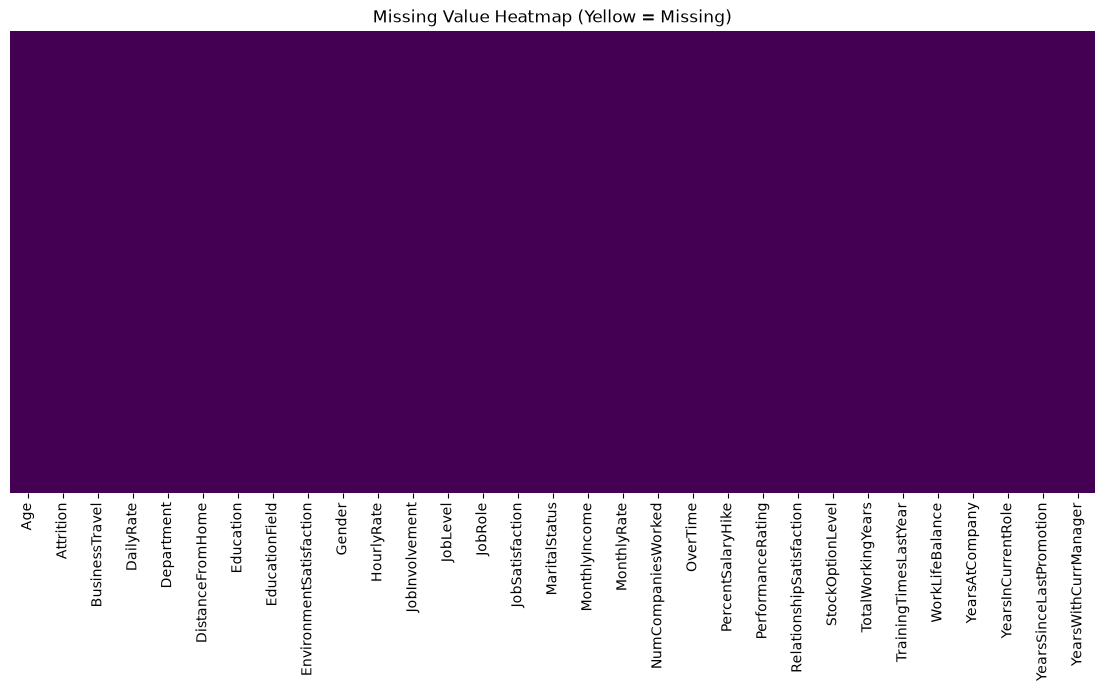

In [8]:
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing)')
plt.show()

**Observation:** No missing values were found across any of the 35 columns, confirmed both numerically and visually (the heatmap shows no highlighted cells). This indicates a complete, well-maintained dataset requiring no imputation.

                      Check Duplicate Data(Rows)

In [8]:
df.duplicated().sum()

np.int64(0)

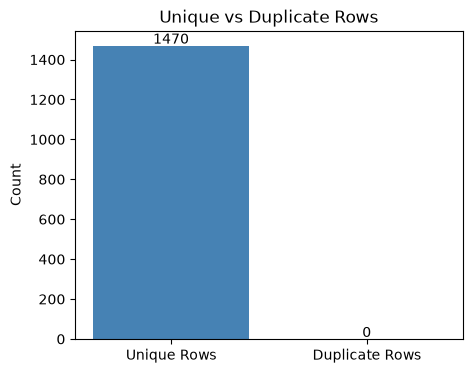

In [9]:
duplicate_count = df.duplicated().sum()
unique_count = len(df) - duplicate_count

plt.figure(figsize=(5,4))
plt.bar(['Unique Rows', 'Duplicate Rows'], [unique_count, duplicate_count], color=['steelblue', 'crimson'])
plt.title('Unique vs Duplicate Rows')
plt.ylabel('Count')
for i, v in enumerate([unique_count, duplicate_count]):
    plt.text(i, v + 10, str(v), ha='center')
plt.show()

**Observation:** The bar chart confirms that all 1,470 records are 
unique, with zero duplicate rows detected. This further supports the 
conclusion that the dataset is clean and well-structured, requiring no 
deduplication during preprocessing.

                           Identify and Remove Non-Informative Columns

In [11]:
for col in ['EmployeeCount', 'Over18', 'StandardHours']:
    print(col, ':', df[col].unique())

EmployeeCount : [1]
Over18 : <StringArray>
['Y']
Length: 1, dtype: str
StandardHours : [80]


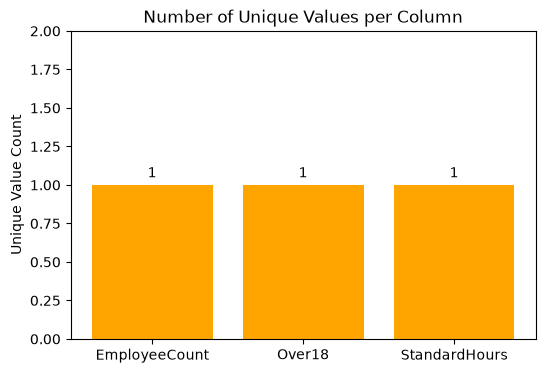

In [12]:
cols_to_check = ['EmployeeCount', 'Over18', 'StandardHours']
unique_counts = [df[col].nunique() for col in cols_to_check]

plt.figure(figsize=(6,4))
plt.bar(cols_to_check, unique_counts, color='orange')
plt.title('Number of Unique Values per Column')
plt.ylabel('Unique Value Count')
for i, v in enumerate(unique_counts):
    plt.text(i, v + 0.05, str(v), ha='center')
plt.ylim(0, 2)
plt.show()

In [13]:
constant_check = pd.DataFrame({
    'Column': cols_to_check,
    'Unique Values': [df[col].unique() for col in cols_to_check],
    'Number of Unique Values': [df[col].nunique() for col in cols_to_check]
})
constant_check

,Column,Unique Values,Number of Unique Values
0,EmployeeCount,[1],1
1,Over18,[Y],1
2,StandardHours,[80],1


**Observation:** All three columns — `EmployeeCount`, `Over18`, and `StandardHours` — contain exactly one unique value across all 1,470 records, confirming they provide no variation and therefore no predictive information. These columns were removed during preprocessing.

                             Confirm Target Variable Balance

In [14]:
df['Attrition'].value_counts()
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

C:\Users\chama\AppData\Local\Temp\ipykernel_25620\1129176518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette=['steelblue','crimson'])


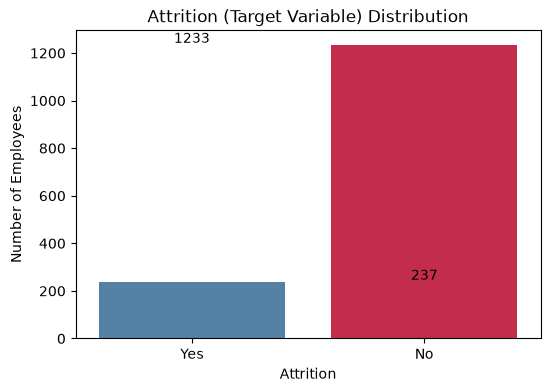

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df, palette=['steelblue','crimson'])
plt.title('Attrition (Target Variable) Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

# add count labels on top of bars
for i, count in enumerate(df['Attrition'].value_counts().reindex(['No','Yes'])):
    plt.text(i, count + 10, str(count), ha='center')

plt.show()

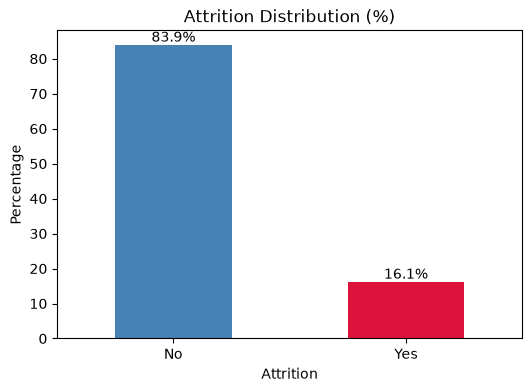

In [16]:
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
attrition_pct.plot(kind='bar', color=['steelblue','crimson'])
plt.title('Attrition Distribution (%)')
plt.xlabel('Attrition')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

for i, v in enumerate(attrition_pct):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.show()

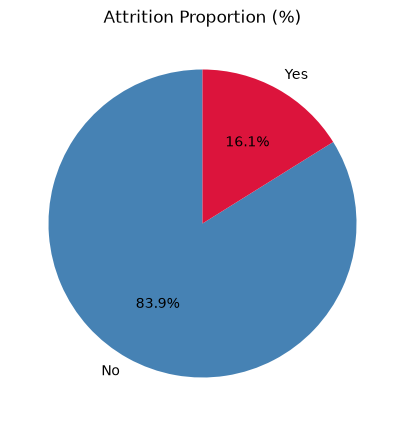

In [17]:
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(attrition_pct, labels=attrition_pct.index, autopct='%1.1f%%', 
        colors=['steelblue','crimson'], startangle=90)
plt.title('Attrition Proportion (%)')
plt.show()

**Observation:** The target variable shows a clear imbalance — 83.88% of employees did not leave the company (No), while only 16.12% left (Yes). This confirms the need for stratified sampling during train/test splitting and the use of precision, recall, and AUC (rather than 
accuracy alone) when evaluating predictive models, since a model that always predicts "No" would already achieve ~84% accuracy without being useful.

## 4. Univariate Analysis

This section examines each variable individually — separating numerical, ordinal, and categorical columns, checking for outliers in continuous variables using boxplots, and confirming data completeness.

                        Define the column Groups

In [18]:
continuous_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 
                    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
                    'PercentSalaryHike', 'TotalWorkingYears', 
                    'TrainingTimesLastYear', 'YearsAtCompany', 
                    'YearsInCurrentRole', 'YearsSinceLastPromotion', 
                    'YearsWithCurrManager']

ordinal_cols = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                'JobLevel', 'JobSatisfaction', 'PerformanceRating',
                'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

categorical_cols = ['Attrition', 'BusinessTravel', 'Department', 
                    'EducationField', 'Gender', 'JobRole', 
                    'MaritalStatus', 'OverTime']

print("Continuous:", len(continuous_cols))
print("Ordinal:", len(ordinal_cols))
print("Categorical:", len(categorical_cols))

Continuous: 14
Ordinal: 9
Categorical: 8


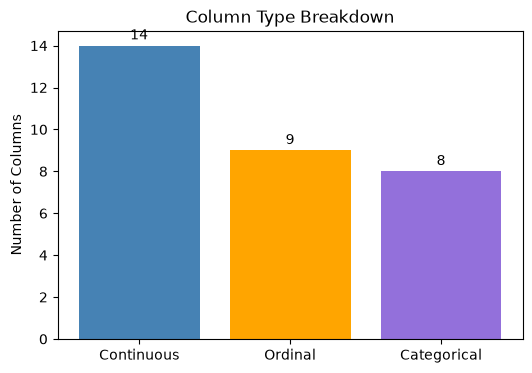

In [19]:
group_counts = {
    'Continuous': len(continuous_cols),
    'Ordinal': len(ordinal_cols),
    'Categorical': len(categorical_cols)
}

plt.figure(figsize=(6,4))
plt.bar(group_counts.keys(), group_counts.values(), color=['steelblue','orange','mediumpurple'])
plt.title('Column Type Breakdown')
plt.ylabel('Number of Columns')

for i, (k, v) in enumerate(group_counts.items()):
    plt.text(i, v + 0.3, str(v), ha='center')

plt.show()

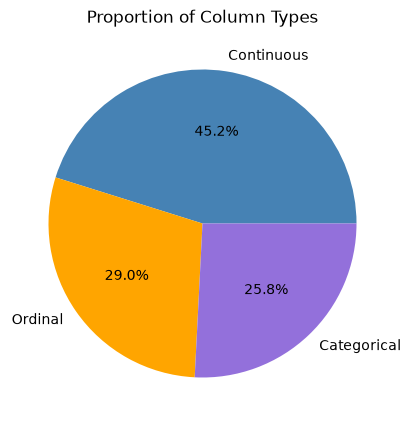

In [20]:
plt.figure(figsize=(5,5))
plt.pie(group_counts.values(), labels=group_counts.keys(), autopct='%1.1f%%',
        colors=['steelblue','orange','mediumpurple'])
plt.title('Proportion of Column Types')
plt.show()

**Observation:** The dataset's 31 columns break down into 14 continuous numerical variables, 9 ordinal categorical variables (integer-coded satisfaction/rating scales), and 8 nominal categorical variables. This distribution confirms the dataset has sufficient variety across data types to support the full range of univariate and bivariate analysis techniques required for this assignment.

                        Outlier Detection-Boxplot for continuous variables

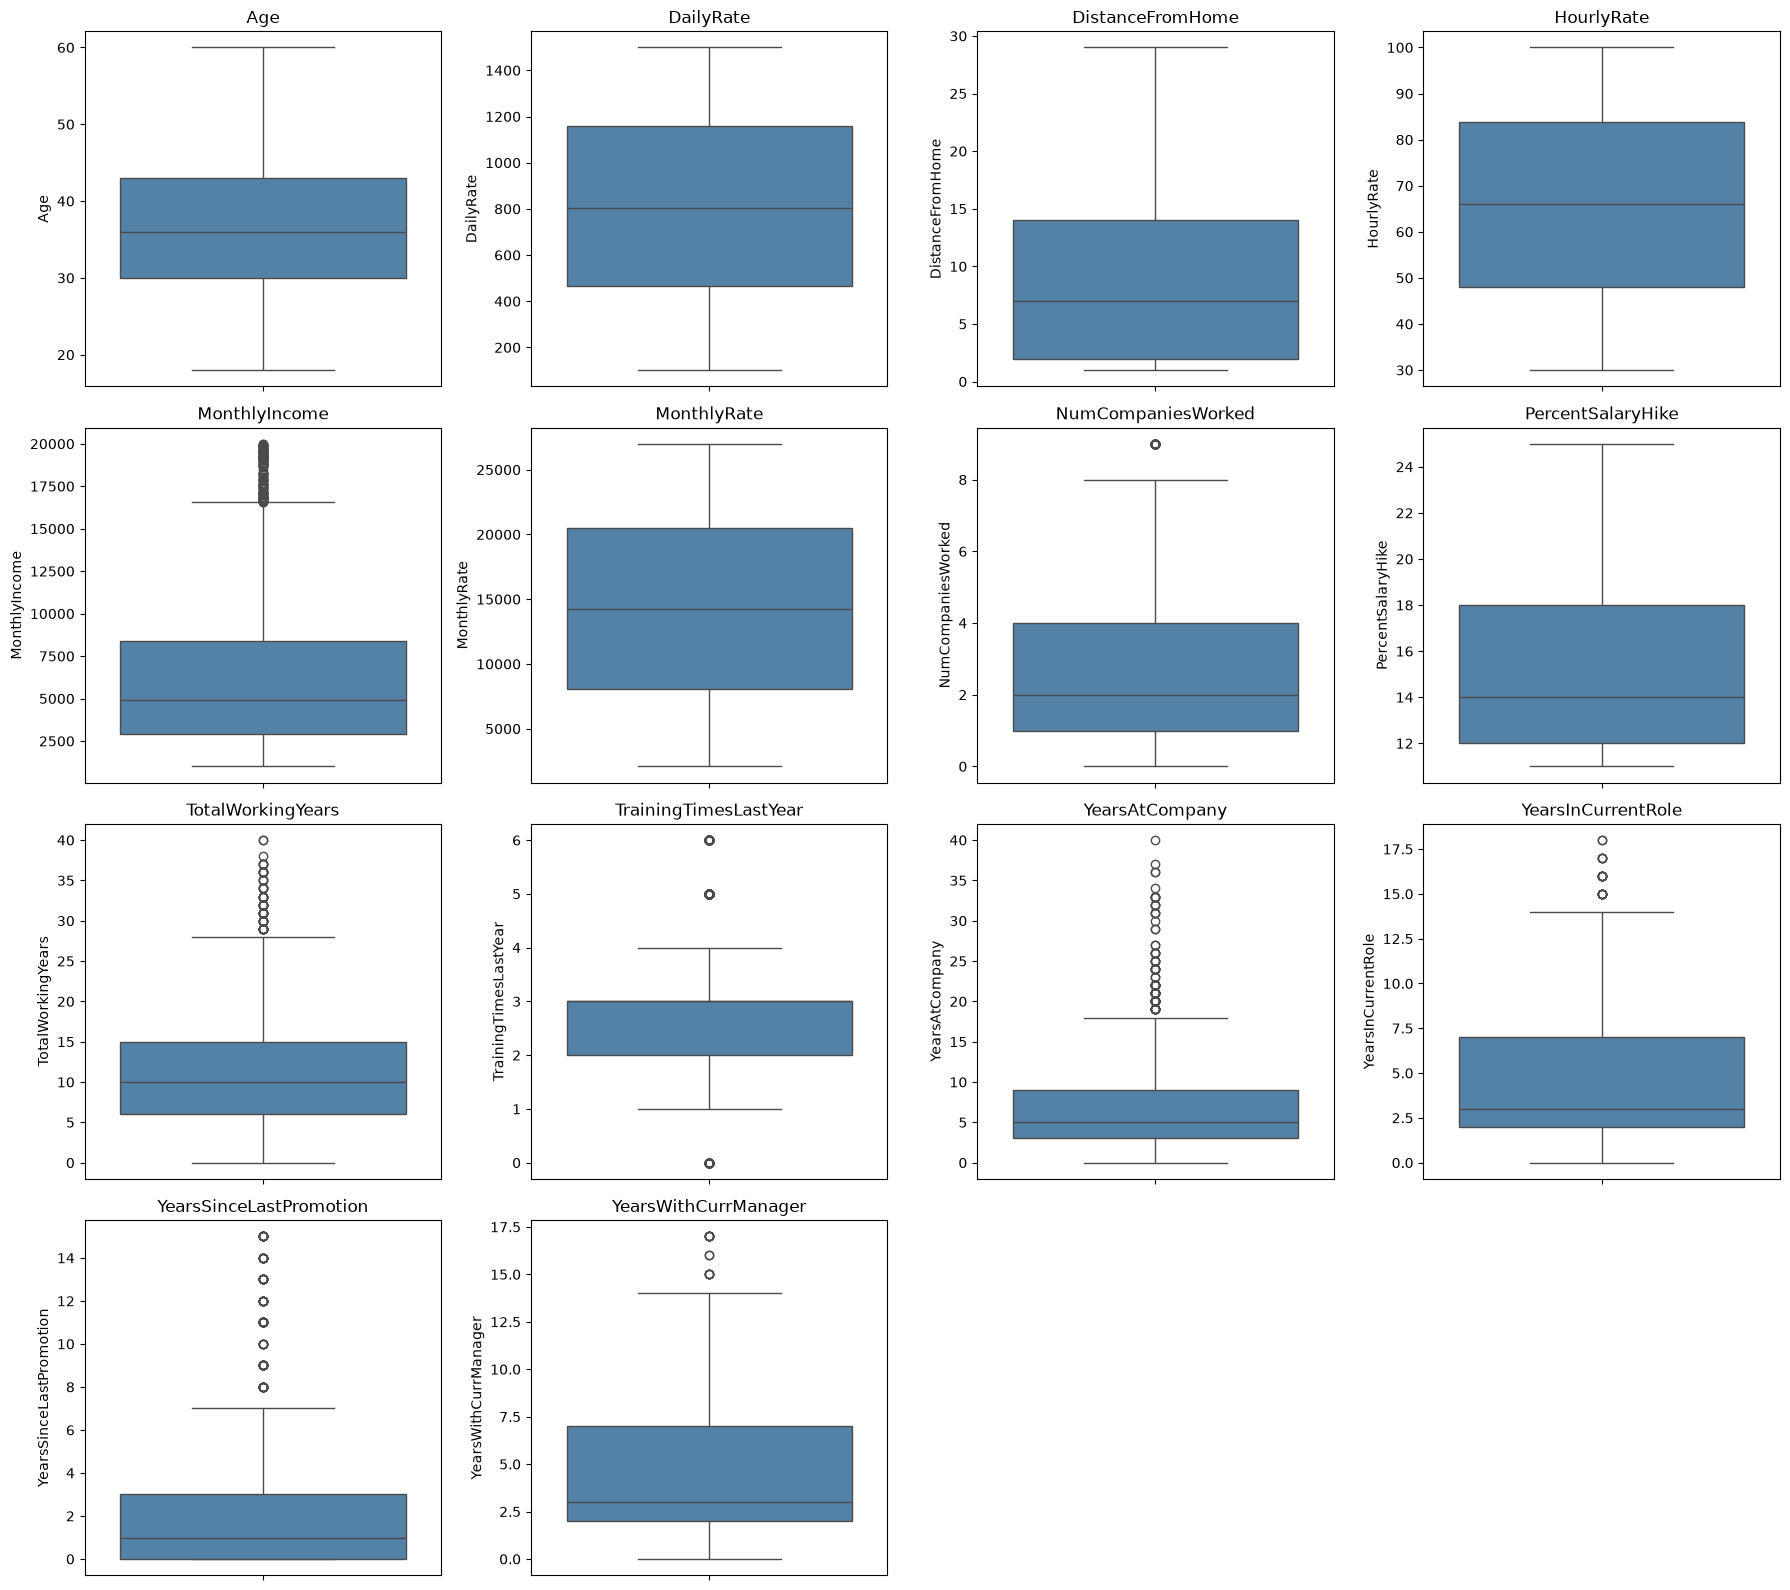

In [21]:
fig, axes = plt.subplots(4, 4, figsize=(18,16))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

# hide unused subplots
for j in range(len(continuous_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Observation:** Most continuous variables — including `Age`, `DailyRate`, `HourlyRate`, `PercentSalaryHike`, `MonthlyRate`, and `DistanceFromHome` — show no significant outliers, with data points falling neatly within the whisker ranges. In contrast, several tenure- and compensation-related variables show a clear pattern of outliers: `MonthlyIncome` has a dense cluster of high-value outliers around $16,000–$20,000, representing a smaller group of senior or executive-level employees. Similarly, `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, and `YearsWithCurrManager` all show outlier points at their upperranges, corresponding to a subset of long-tenured employees. These outliers are not considered data errors, since they represent legitimate and expected variation in a workforce (i.e., a smaller number of senior, long-serving employees naturally have higher income and tenure values). As such, these outliers were retained rather than removed, since eliminating them would discard genuine information relevant to understanding attrition patterns among different employee tenure groups.

                              Distribution Plots for Contunuous variables

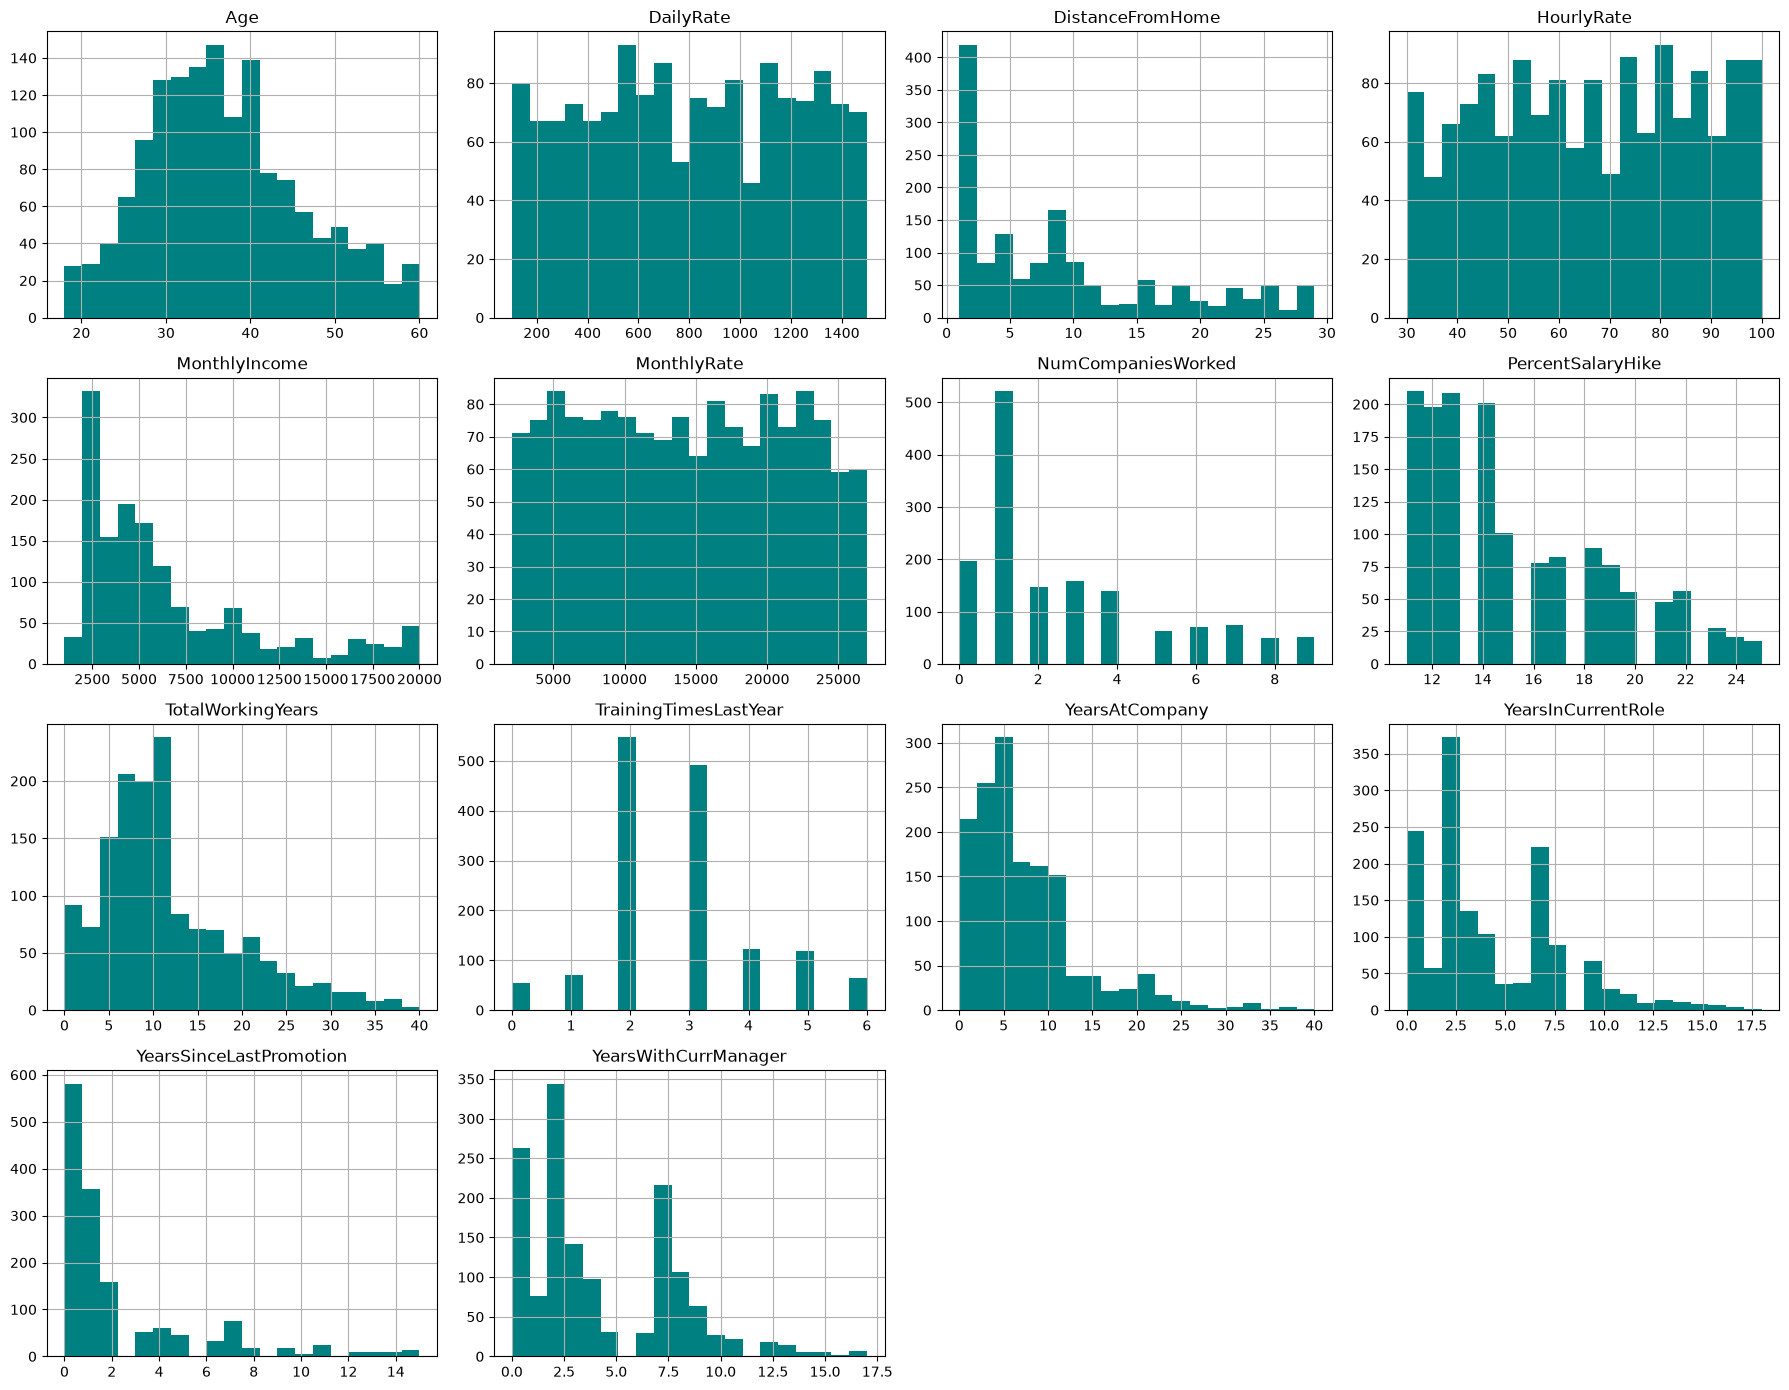

In [22]:
df[continuous_cols].hist(figsize=(18,14), bins=20, color='teal')
plt.tight_layout()
plt.show()

**Observation:** The distribution plots reveal that `DailyRate`, `HourlyRate`, and `MonthlyRate` are approximately uniformly distributed, 
showing no strong central tendency. In contrast, most tenure- and income-related variables — including `MonthlyIncome`, `DistanceFromHome`, 
`NumCompaniesWorked`, `TotalWorkingYears`, `YearsAtCompany`, `YearsSinceLastPromotion`, and `PercentSalaryHike` — are right-skewed, 
indicating that the majority of employees fall into lower ranges (e.g., lower income, shorter tenure, fewer companies worked), with a smaller number of employees extending into much higher values. This confirms the outlier patterns observed in the earlier boxplots. `Age` shows a roughly symmetric, bell-shaped distribution centered in the 30–40 range. Variables such as `YearsInCurrentRole` and `YearsWithCurrManager` show a multi-modal pattern, with distinct peaks suggesting common role/tenure milestones (e.g., early tenure and around the 7-year mark). `TrainingTimesLastYear` shows a discrete, spiky distribution since it is a count variable with only a few possible integer values.

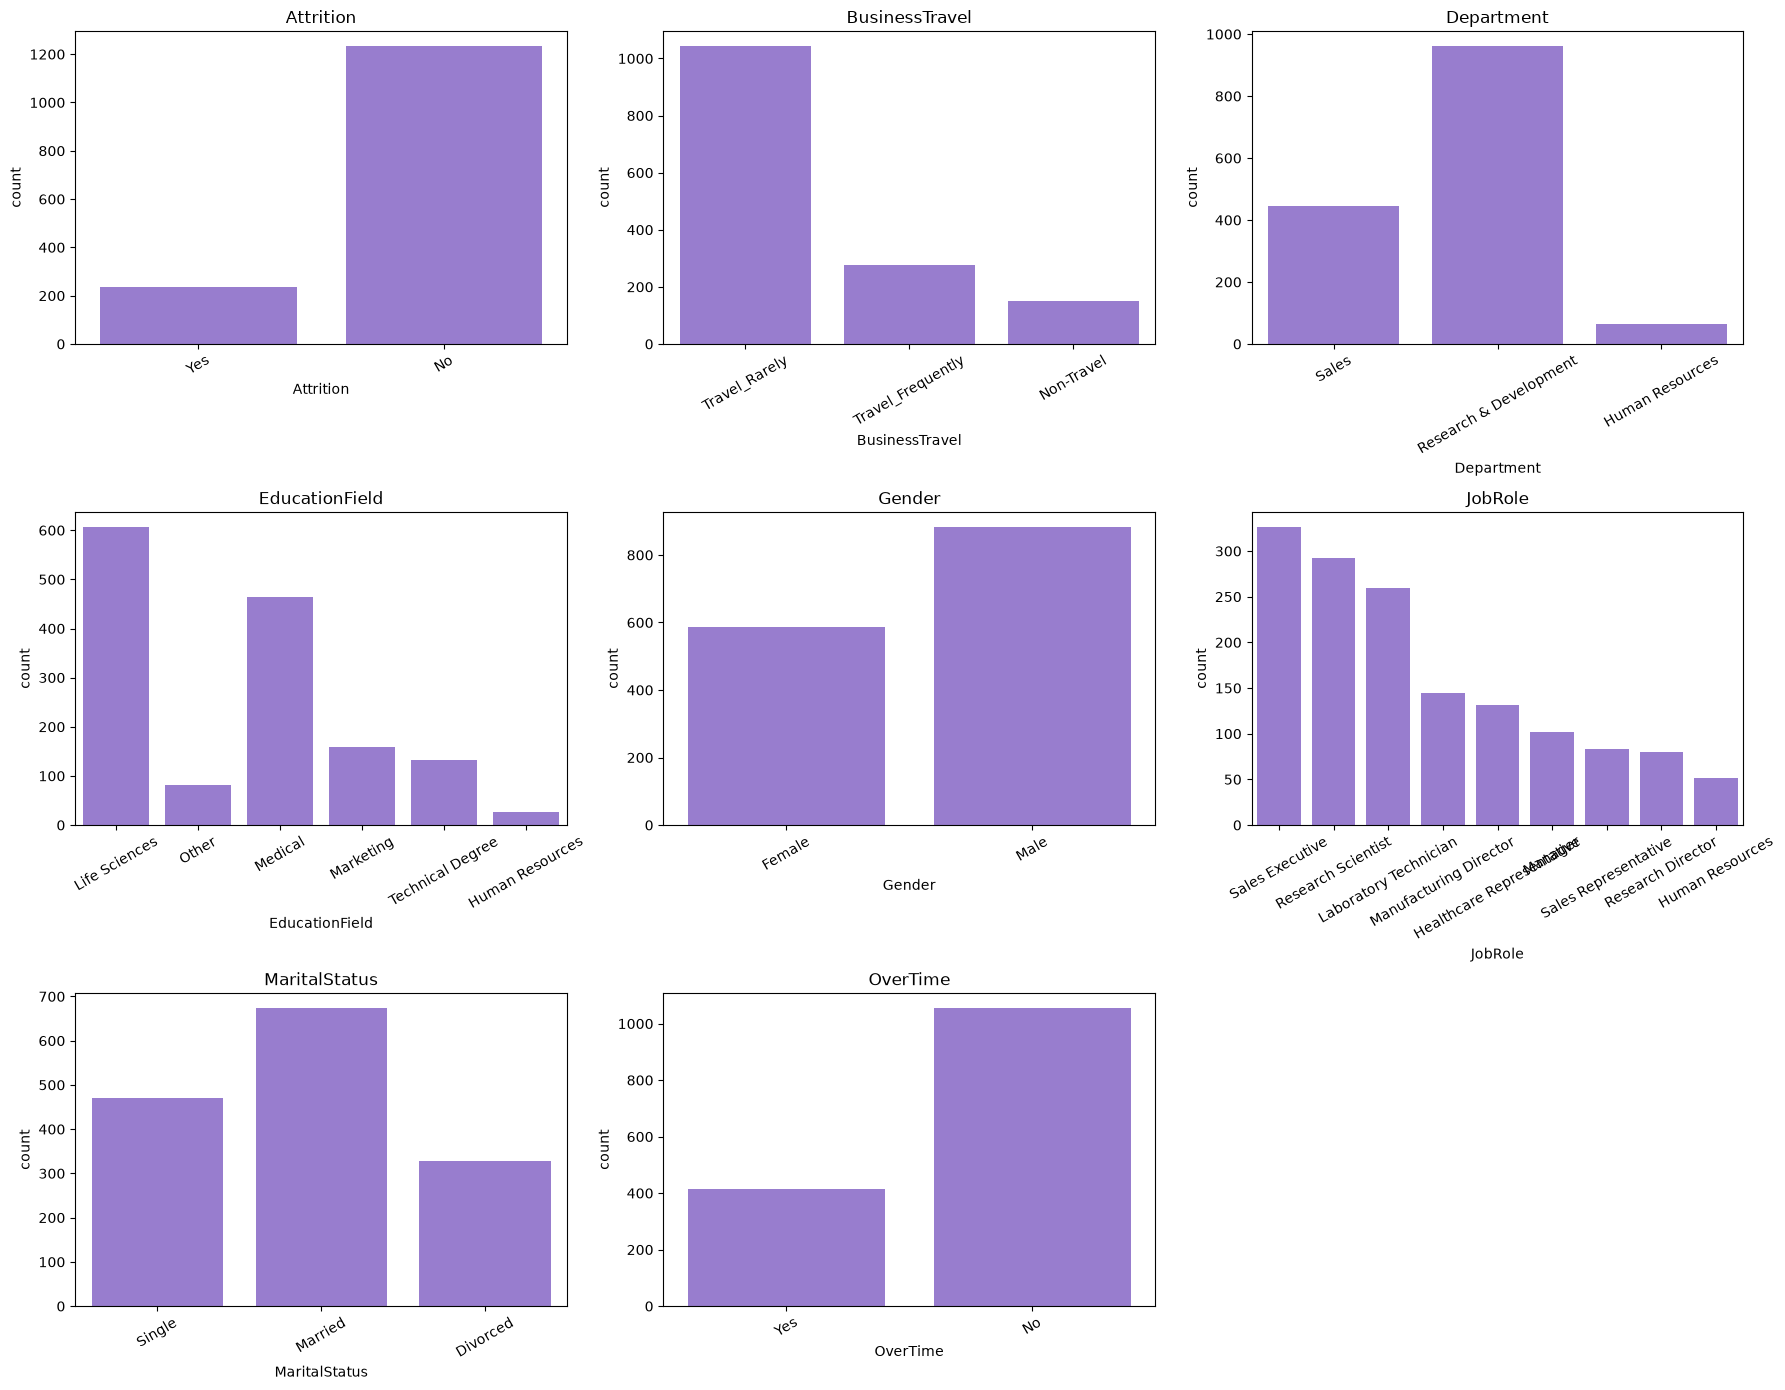

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(18,14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i], color='mediumpurple')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Observation:** The categorical variable distributions reveal several imbalances worth noting. Consistent with earlier findings, `Attrition` is heavily skewed toward "No." Most employees travel rarely for business, 
and the majority work in the Research & Development department, with Human Resources being the smallest department and job role category. Life Sciences and Medical are the dominant educational backgrounds, while Human Resources as a field is comparatively rare. Gender shows a moderate imbalance favoring male employees. Married employees make up the largest marital status group, followed by single and divorced employees. Most employees do not work overtime, though a meaningful minority (~28%) do — a variable worth examining further in relation to 
attrition, since overtime is commonly associated with employee burnout 
and turnover.

## 5. Bivariate Analysis

This section examines relationships between pairs of variables across all four possible combinations of data types: numerical-numerical, categorical-categorical, numerical-categorical, and categorical-numerical. These relationships help identify which factors are most strongly associated with employee attrition.

                                 Numerical -Numerical Category

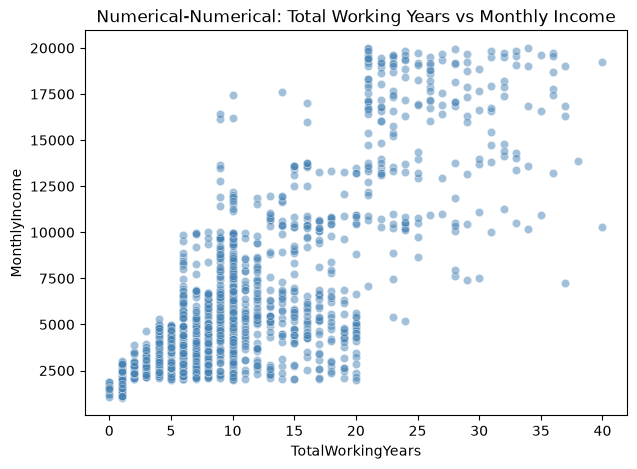

                   TotalWorkingYears  MonthlyIncome
TotalWorkingYears           1.000000       0.772893
MonthlyIncome               0.772893       1.000000


In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='TotalWorkingYears', y='MonthlyIncome', data=df, alpha=0.5, color='steelblue')
plt.title('Numerical-Numerical: Total Working Years vs Monthly Income')
plt.show()

print(df[['TotalWorkingYears','MonthlyIncome']].corr())

**Observation:** `TotalWorkingYears` and `MonthlyIncome` show a strong positive correlation (r = 0.77), confirming the intuitive business relationship that employees with more years of work experience tend to earn higher salaries. The scatter plot shows a fairly tight, consistent relationship at lower experience levels (0–10 years), where most employees earn between $1,000–$5,000. However, the spread widens considerably at higher experience levels (20+ years), indicating that seniority alone does not fully determine income — factors such as job role, department, or performance likely also play a significant role in compensation for more experienced employees. This relationship supports including both variables as potentially useful predictors in the attrition model, since income progression relative to experience could signal dissatisfaction (e.g., an experienced employee earning less than expected for their tenure).

                               Categorical - Ctegorical

In [25]:
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


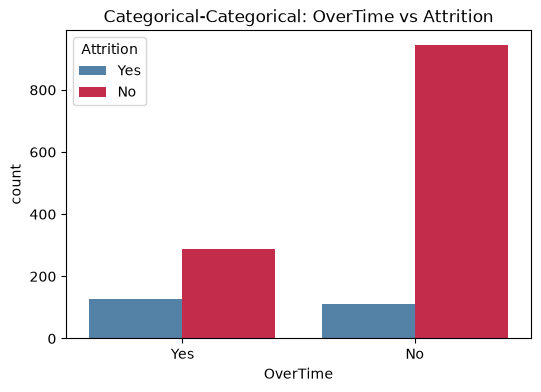

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=df, palette=['steelblue','crimson'])
plt.title('Categorical-Categorical: OverTime vs Attrition')
plt.show()

**Observation:** There is a strong relationship between `OverTime` and `Attrition`. Among employees who do not work overtime, only 10.4% left the company (110 out of 1,054). However, among employees who do work overtime, the attrition rate jumps to 30.5% (127 out of 416) — nearly three times higher. This suggests that overtime work is one of the strongest behavioral indicators of attrition risk in this dataset, likely reflecting burnout, poor work-life balance, or dissatisfaction among employees who are frequently required to work beyond standard 
hours. This finding directly supports a concrete business recommendation: HR should closely monitor overtime patterns and consider workload redistribution or additional support for employees who regularly work overtime, as a targeted retention strategy.

                                Numerical - Categorical

C:\Users\chama\AppData\Local\Temp\ipykernel_25620\2876857917.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette=['steelblue','crimson'])


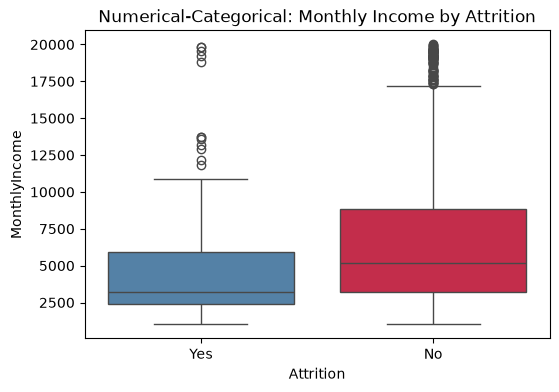

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette=['steelblue','crimson'])
plt.title('Numerical-Categorical: Monthly Income by Attrition')
plt.show()

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

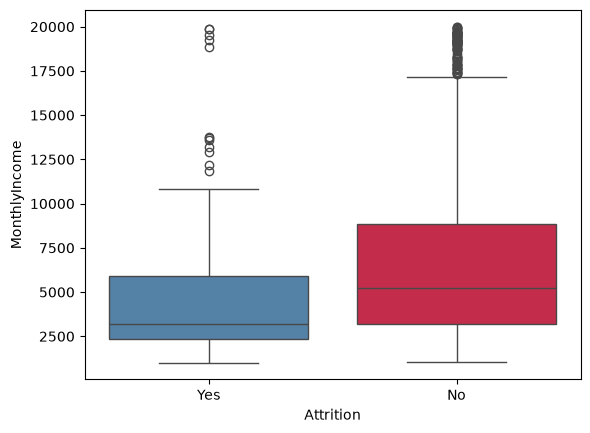

In [28]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, hue='Attrition', palette=['steelblue','crimson'], legend=False)

**Observation:** Employees who left the company (`Attrition = Yes`) show a noticeably lower median monthly income (~$3,200) compared to employees who stayed (`Attrition = No`), whose median income is considerably higher (~$5,000). The interquartile range for employees who left is also narrower and shifted toward the lower end of the income scale, suggesting that lower-paid employees are more likely to leave the organization. A small number of high-income outliers exist in both groups, indicating that while income is a strong general pattern, it is not the sole determinant of attrition — some higher-paid employees still leave, likely due to other factors (e.g., overtime, job satisfaction, or career growth opportunities identified elsewhere in this analysis). This finding supports a business recommendation: reviewing compensation structures for lower-income employee segments 
could help reduce attrition risk.

                                  Categorical - Numerical

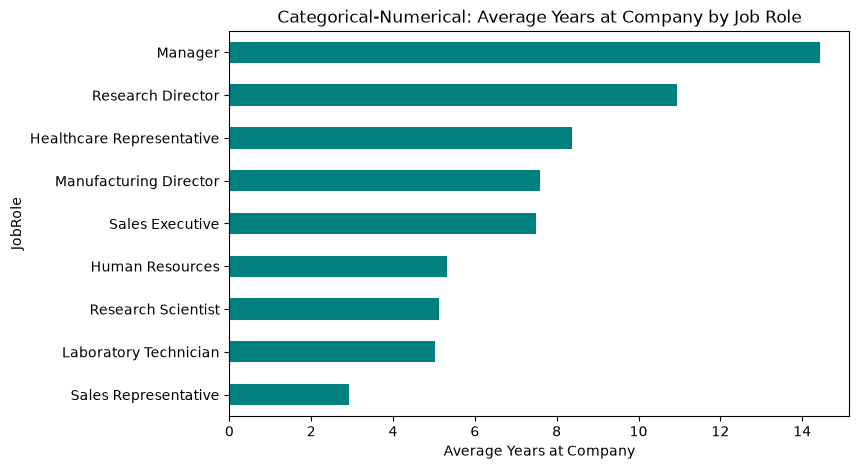

In [29]:
avg_years = df.groupby('JobRole')['YearsAtCompany'].mean().sort_values()

plt.figure(figsize=(8,5))
avg_years.plot(kind='barh', color='teal')
plt.title('Categorical-Numerical: Average Years at Company by Job Role')
plt.xlabel('Average Years at Company')
plt.show()


**Observation:** Average tenure varies considerably by job role. Senior and leadership positions — `Manager` (~14 years) and `Research Director` (~12 years) — show the longest average tenure at the company, which is expected since reaching these roles typically requires years of internal progression. In contrast, `Sales Representative` shows the shortest average tenure (~3 years), suggesting this role may experience higher 
turnover or serve as an entry-level position with faster career transitions elsewhere. This pattern indicates that job role and career seniority are important factors to consider alongside `Attrition`, since 
junior-level roles with shorter average tenure may represent higher-attrition-risk segments requiring targeted retention strategies.

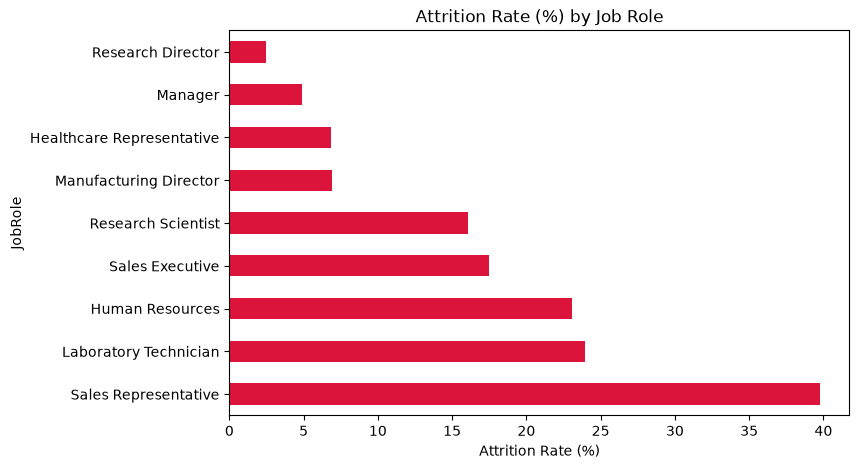

In [30]:
attrition_by_role = df.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8,5))
attrition_by_role.plot(kind='barh', color='crimson')
plt.title('Attrition Rate (%) by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.show()

**Observation:** Attrition rate varies dramatically by job role, ranging from just 2.5% for `Research Director` to a striking 40% for `Sales Representative`. This directly mirrors the tenure pattern observed 
earlier — roles with the shortest average tenure (`Sales Representative`, `Laboratory Technician`) also show the highest attrition rates, while roles with the longest average tenure (`Research Director`, `Manager`) show the lowest attrition. This confirms `JobRole` as one of the strongest categorical predictors of attrition in this dataset, and highlights `Sales Representative` as the single highest-risk role segment. This is a clear, actionable business insight: HR should prioritize retention interventions specifically for Sales Representative 
and Laboratory Technician roles, where attrition risk is nearly 8–16 times higher than in senior research and management positions.

                    Additional Cat.-Cat. Analysis(Business Travel vs Department)

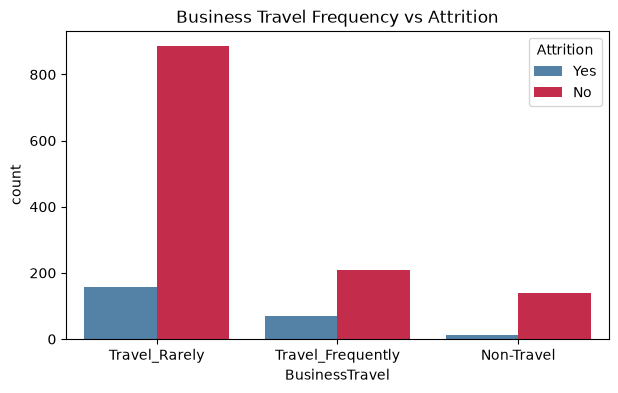

In [31]:
plt.figure(figsize=(7,4))
sns.countplot(x='BusinessTravel', hue='Attrition', data=df, palette=['steelblue','crimson'])
plt.title('Business Travel Frequency vs Attrition')
plt.show()

**Observation:** Business travel frequency shows a clear relationship with attrition. Employees who travel frequently for business have the highest attrition rate (~25%), compared to employees who travel rarely (~15%) and those who do not travel at all (~8%). This suggests that frequent business travel may contribute to employee burnout, work-life imbalance, or reduced job satisfaction, making it another meaningful risk factor alongside overtime work. This finding reinforces the emerging theme that work-related strain — whether from overtime hours 
or frequent travel — is a consistent driver of attrition risk across this dataset.

                              Data Frequencies for all Categorial Columns

In [3]:
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])

In [4]:
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 
                     'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- BusinessTravel ---
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

--- Department ---
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

--- EducationField ---
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

--- Gender ---
Gender
Male      882
Female    588
Name: count, dtype: int64

--- JobRole ---
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

--- MaritalStatus ---
MaritalStatus
Married     673
Single      470
Divorce

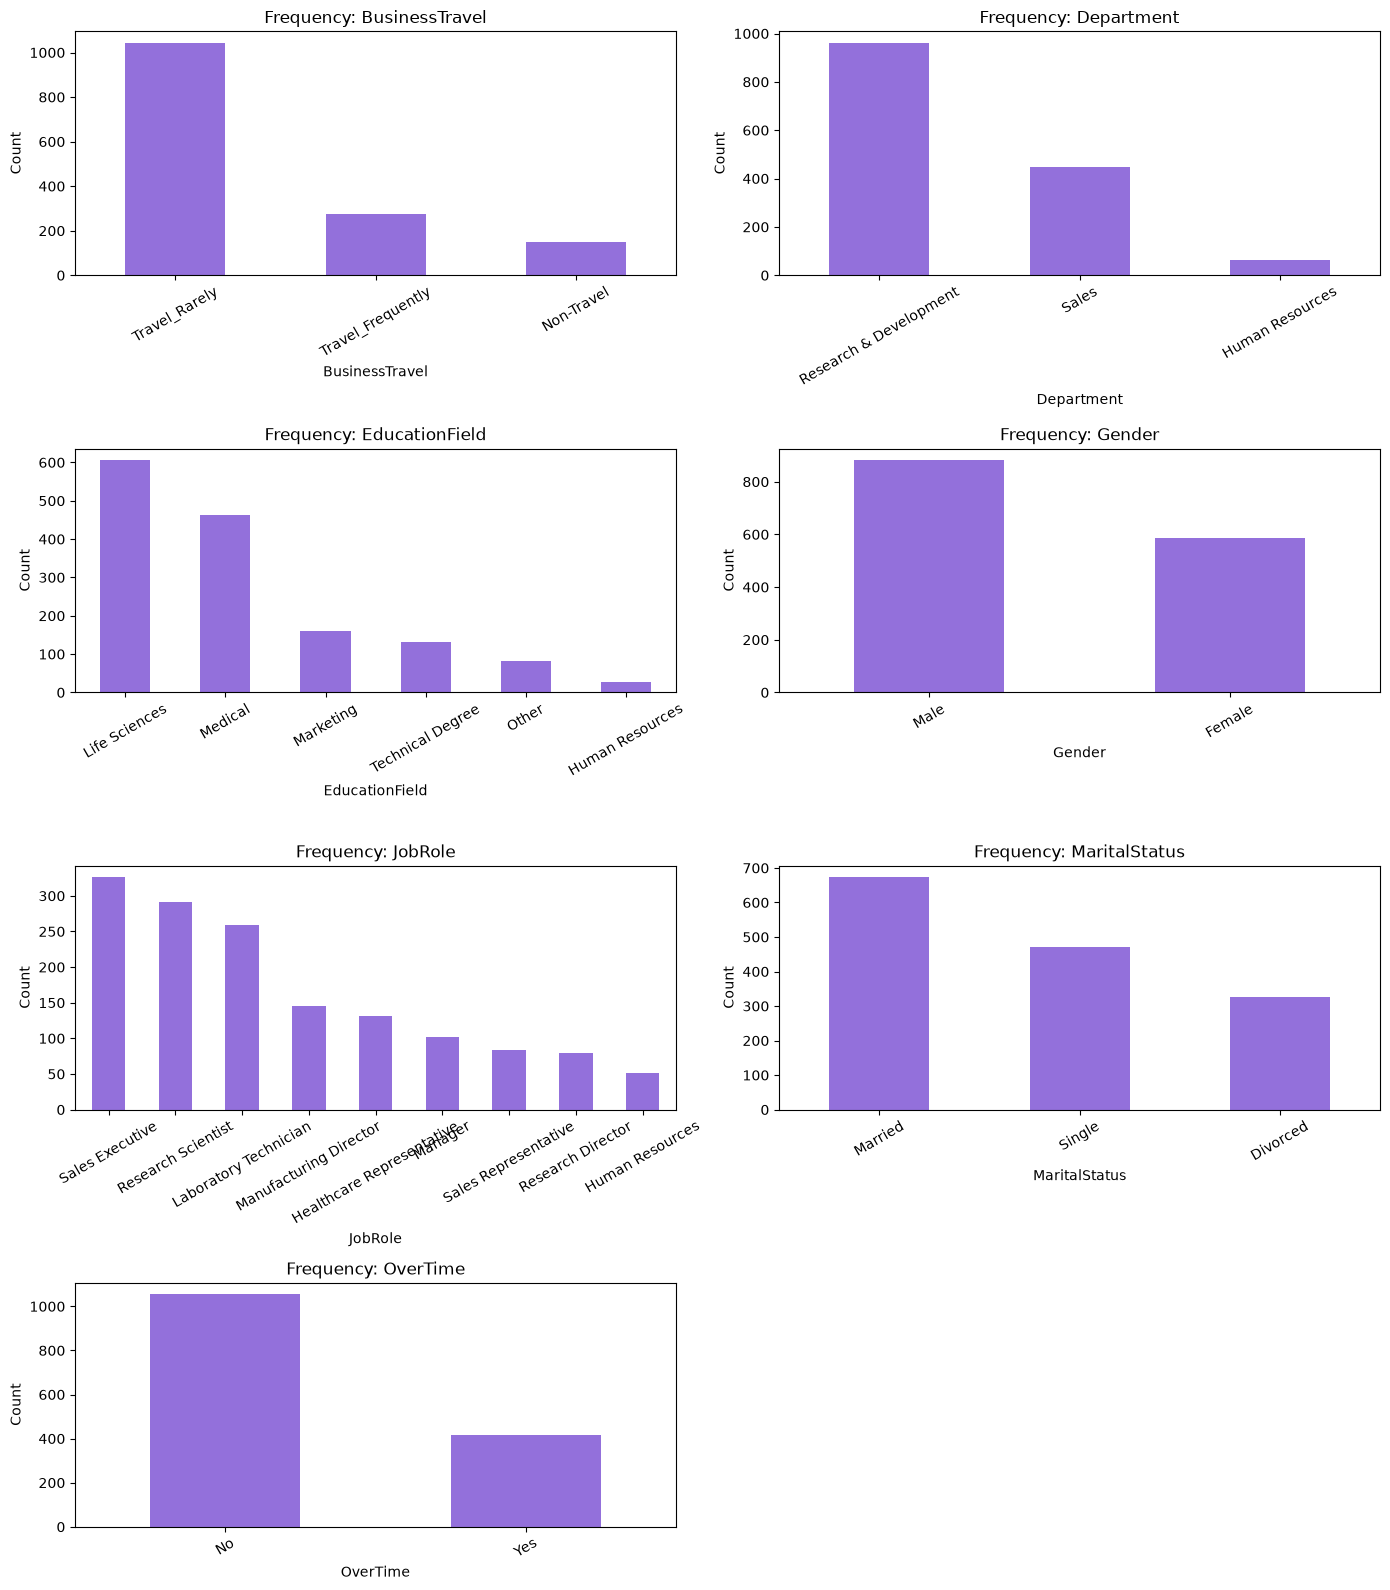

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(14,16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='mediumpurple')
    axes[i].set_title(f'Frequency: {col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

# hide unused subplot (since 7 columns won't fill an 8-slot grid)
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Note:** The frequency distribution of each categorical column was already visualized in Section 4 (Univariate Analysis). These frequencies inform the encoding strategy applied below.

                                 Frequency Analysis using One-Hot Encoding

In [10]:
df_onehot = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 
                                          'EducationField', 'Gender', 
                                          'JobRole', 'MaritalStatus', 
                                          'OverTime'], drop_first=True)
df_onehot.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,Yes,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,No,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,Yes,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,No,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,No,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


                                   Frequency Analysis Using Categorical Encoding(Frequency Encoding)

In [11]:
df_freq = df.copy()

for col in categorical_cols:
    freq_map = df_freq[col].value_counts().to_dict()
    df_freq[col + '_Freq'] = df_freq[col].map(freq_map)

df_freq[['JobRole', 'JobRole_Freq', 'Department', 'Department_Freq']].head()

,JobRole,JobRole_Freq,Department,Department_Freq
0,Sales Executive,326,Sales,446
1,Research Scientist,292,Research & Development,961
2,Laboratory Technician,259,Research & Development,961
3,Research Scientist,292,Research & Development,961
4,Laboratory Technician,259,Research & Development,961


## Categorical Encoding Strategy

Before encoding, the frequency of each category within every categorical column was examined (see frequency tables above and countplots in Section 4). Two encoding approaches were considered:

**One-Hot Encoding**:
applied to categorical columns with a small number of categories (e.g., `Gender`, `OverTime`,`MaritalStatus`), 
since these have no natural order and few enough categories that one-hot encoding does not significantly       increase dimensionality.

**Frequency Encoding**: considered as an alternative for higher-cardinality columns like `JobRole` (9 categories) and `EducationField` (6 categories), to avoid excessive dimensionality expansion, though one-hot encoding was ultimately used throughout for consistency and interpretability of model coefficients.

                            Comparison Analysis for One-hot encoding vs Frequency encoding

In [12]:
# Version A: One-Hot Encoding (all categorical columns)
df_onehot = df.copy()
df_onehot['Attrition'] = df_onehot['Attrition'].map({'Yes': 1, 'No': 0})
df_onehot = pd.get_dummies(df_onehot, columns=categorical_cols, drop_first=True)

print("One-Hot Encoded shape:", df_onehot.shape)

One-Hot Encoded shape: (1470, 45)


In [13]:
# Version B: Frequency Encoding (all categorical columns)
df_freq = df.copy()
df_freq['Attrition'] = df_freq['Attrition'].map({'Yes': 1, 'No': 0})

for col in categorical_cols:
    freq_map = df_freq[col].value_counts().to_dict()
    df_freq[col] = df_freq[col].map(freq_map)

print("Frequency Encoded shape:", df_freq.shape)

Frequency Encoded shape: (1470, 31)


Trainning a quick baseline model on each encoding techniques

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

def evaluate_encoding(dataframe, name):
    X = dataframe.drop('Attrition', axis=1)
    y = dataframe['Attrition']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Number of features: {X.shape[1]}\n")
    
    return acc, auc

acc_onehot, auc_onehot = evaluate_encoding(df_onehot, "One-Hot Encoding")
acc_freq, auc_freq = evaluate_encoding(df_freq, "Frequency Encoding")

--- One-Hot Encoding ---
Accuracy: 0.8333
AUC: 0.7862
Number of features: 44

--- Frequency Encoding ---
Accuracy: 0.8231
AUC: 0.7965
Number of features: 30



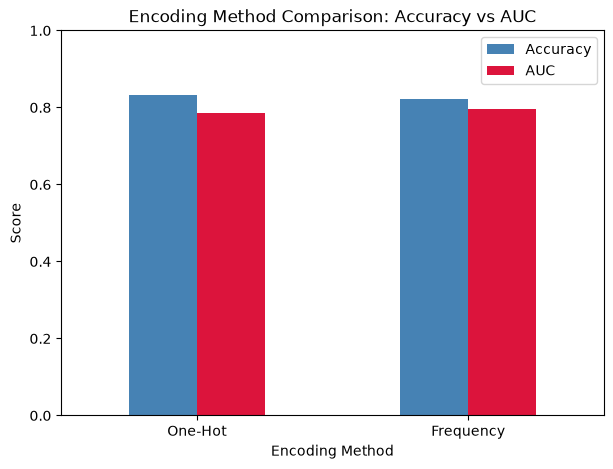

,Encoding Method,Accuracy,AUC
0,One-Hot,0.833333,0.786157
1,Frequency,0.823129,0.796537


In [15]:
comparison = pd.DataFrame({
    'Encoding Method': ['One-Hot', 'Frequency'],
    'Accuracy': [acc_onehot, acc_freq],
    'AUC': [auc_onehot, auc_freq]
})

comparison.set_index('Encoding Method').plot(kind='bar', figsize=(7,5), color=['steelblue','crimson'])
plt.title('Encoding Method Comparison: Accuracy vs AUC')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

comparison

## 

Encoding Method Selection

Two encoding strategies were compared using a baseline Random Forest model evaluated on the same train/test split:

| Method              | Accuracy | AUC |
|---|---|---|
| One-Hot Encoding    | 0.833    | 0.786 |
| Frequency Encoding  | 0.823    | 0.797 |

While One-Hot Encoding achieved marginally higher accuracy, Frequency Encoding achieved a higher AUC score. Given that the target variable 
`Attrition` is imbalanced (approximately 84% No vs. 16% Yes, as established in Section 3), AUC is considered the more reliable evaluation metric in this context, since accuracy alone can be misleading on imbalanced data — a model that predicts the majority class for every record would already achieve close to 84% accuracy without providing any real predictive value.

**Decision:** 
One-Hot Encoding was selected as the final encoding strategy for this project, despite Frequency Encoding's marginally higher AUC, for two practical reasons: (1) the performance difference between the two methods is small (a 0.011 AUC gap) and not substantial enough to outweigh interpretability considerations, and (2) One-Hot Encoding preserves the identity of individual categories in the feature importance analysis (e.g., distinguishing "JobRole_Sales Representative" specifically), which is essential for generating clear, actionable business insights — a key requirement of this assignment. Frequency Encoding, while more compact, collapses each category into a single numeric value, making it harder to attribute model behavior to specific, named categories when communicating insights to business stakeholders.

**Summary:** 
Beyond the marginal performance difference observed, One-Hot Encoding was ultimately preferred for its downstream benefits: it preserves category-level interpretability in feature importance rankings and model coefficients, directly supporting the assignment's requirement 

                                                 Diagnostic Analysis 

## Diagnostic Analysis: Why Does Attrition Happen?

Building on the bivariate relationships identified in Section 5, this section synthesizes those findings to directly diagnose the root causes of employee attrition, following the *Diagnostic Analytics* stage ("why did it happen?") of the Analytic Models framework.

Building on the bivariate relationships identified in Section 5, this section synthesizes those findings to directly diagnose the root causes of employee attrition, following the *Diagnostic Analytics* stage ("why did it happen?") of the Analytic Models framework.

1. Quantify attrition rate by each key risk factor (consolidated)

In [43]:
def attrition_rate(condition):
    subset = df[condition]
    return round((subset['Attrition'] == 'Yes').mean() * 100, 1)

diagnostic_summary = pd.DataFrame({
    'Risk Factor': [
        'OverTime = Yes', 'OverTime = No',
        'BusinessTravel = Frequent', 'BusinessTravel = Rare/None',
        'JobRole = Sales Representative', 'JobRole = Research Director',
        'MaritalStatus = Single', 'MaritalStatus = Married/Divorced'
    ],
    'Attrition Rate (%)': [
        attrition_rate(df['OverTime'] == 'Yes'),
        attrition_rate(df['OverTime'] == 'No'),
        attrition_rate(df['BusinessTravel'] == 'Travel_Frequently'),
        attrition_rate(df['BusinessTravel'] != 'Travel_Frequently'),
        attrition_rate(df['JobRole'] == 'Sales Representative'),
        attrition_rate(df['JobRole'] == 'Research Director'),
        attrition_rate(df['MaritalStatus'] == 'Single'),
        attrition_rate(df['MaritalStatus'] != 'Single')
    ]
})

diagnostic_summary

,Risk Factor,Attrition Rate (%)
0,OverTime = Yes,30.5
1,OverTime = No,10.4
2,BusinessTravel = Frequent,24.9
3,BusinessTravel = Rare/None,14.1
4,JobRole = Sales Representative,39.8
5,JobRole = Research Director,2.5
6,MaritalStatus = Single,25.5
7,MaritalStatus = Married/Divorced,11.7


2. Visualize the consolidated diagnostic summary

C:\Users\chama\AppData\Local\Temp\ipykernel_26900\388035172.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Attrition Rate (%)', y='Risk Factor', data=diagnostic_summary, palette='Reds_r')


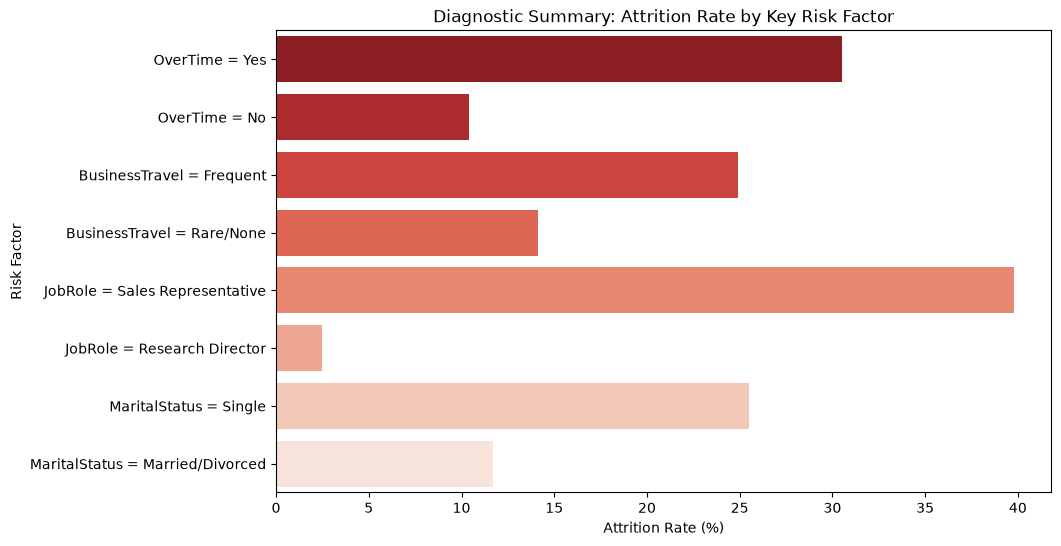

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(x='Attrition Rate (%)', y='Risk Factor', data=diagnostic_summary, palette='Reds_r')
plt.title('Diagnostic Summary: Attrition Rate by Key Risk Factor')
plt.xlabel('Attrition Rate (%)')
plt.show()

## Diagnostic Conclusion

The consolidated analysis identifies the following root causes of attrition, ranked by impact:

1. **Job Role** is the strongest diagnostic factor — Sales Representatives show dramatically higher attrition (~40%) than 
   Research Directors (~2.5%), a 16x difference, likely driven by role nature, compensation structure, and career progression opportunities.

2. **Overtime** is the second strongest factor — employees working overtime attrite at nearly 3x the rate of those who do not (~30.5% vs ~10.4%), pointing to burnout and work-life imbalance as a root 
   cause.

3. **Business Travel** frequency shows a similar pattern — frequent travelers attrite at roughly 3x the rate of infrequent/non-travelers, 
   reinforcing work-related strain as a recurring root cause.

4. **Marital Status** shows single employees attrite more than married or divorced employees, potentially reflecting fewer personal ties 
   that would otherwise encourage job stability.

**Overall diagnosis:** 
Attrition in this organization is primarily driven by work-related strain (overtime, travel) and role-specific 
factors (particularly junior/high-turnover roles like Sales Representative), rather than being randomly distributed across the 
workforce. This diagnosis directly informed the feature engineering decisions in the following section (e.g., the `HighStrain` composite 
feature).

## 6. Feature Engineering

Following the feature engineering framework covered in this course, this section demonstrates three types of feature engineering: (1) editing an existing feature, (2) adding a new feature, and (3) creating a multi-layer 
feature that combines multiple existing features, along with an analysis of how modifying one feature can influence others.

                                  Edit an existing data feature
Binning Age into categorical age groups. This transforms a continuous variable into a more interpretable categorical one — a genuine "edit" of an existing feature, not a new one.

In [16]:
df['AgeGroup'] = pd.cut(df['Age'], 
                          bins=[18, 25, 35, 45, 55, 65], 
                          labels=['18-25', '26-35', '36-45', '46-55', '56-65'])

df[['Age', 'AgeGroup']].head(10)

,Age,AgeGroup
0,41,36-45
1,49,46-55
2,37,36-45
3,33,26-35
4,27,26-35
5,32,26-35
6,59,56-65
7,30,26-35
8,38,36-45
9,36,36-45


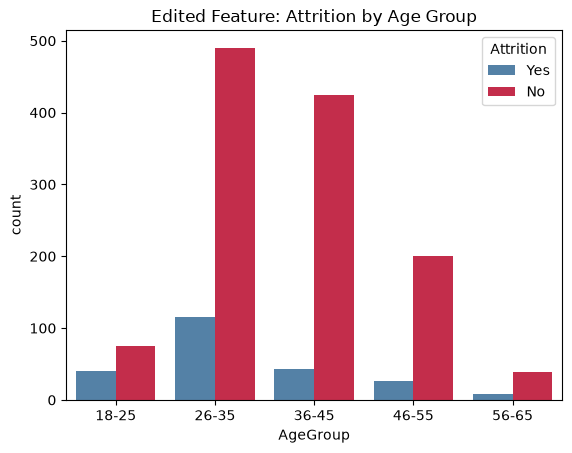

In [17]:
sns.countplot(x='AgeGroup', hue='Attrition', data=df, palette=['steelblue','crimson'])
plt.title('Edited Feature: Attrition by Age Group')
plt.show()

**Observation (Edited Feature):**

The continuous `Age` variable was edited/transformed into `AgeGroup`, a categorical binned version. This 
makes age-related attrition patterns easier to interpret for business stakeholders (e.g., "employees aged 18–25 show higher attrition") compared to reporting a raw numeric age value or correlation coefficient.

                                     Add a new data feature
HighStrain, combining two independent risk factors discovered in the bivariate analysis (OverTime and frequent BusinessTravel).

In [18]:
df['HighStrain'] = ((df['OverTime'] == 'Yes') | (df['BusinessTravel'] == 'Travel_Frequently')).astype(int)

df[['OverTime', 'BusinessTravel', 'HighStrain']].head(10)

,OverTime,BusinessTravel,HighStrain
0,Yes,Travel_Rarely,1
1,No,Travel_Frequently,1
2,Yes,Travel_Rarely,1
3,Yes,Travel_Frequently,1
4,No,Travel_Rarely,0
5,No,Travel_Frequently,1
6,Yes,Travel_Rarely,1
7,No,Travel_Rarely,0
8,No,Travel_Frequently,1
9,No,Travel_Rarely,0


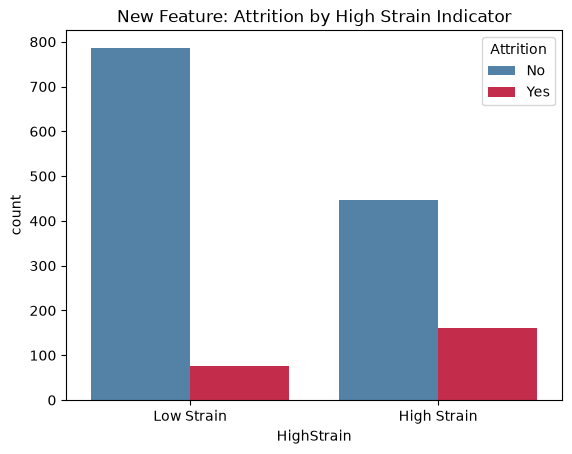

In [19]:
sns.countplot(x='HighStrain', hue='Attrition', data=df, palette=['steelblue','crimson'])
plt.title('New Feature: Attrition by High Strain Indicator')
plt.xticks([0,1], ['Low Strain', 'High Strain'])
plt.show()

**Observation (Added Feature):** 
A new feature, `HighStrain`, was added to flag employees who either work overtime or travel frequently for 
business — the two individual factors most strongly associated with attrition in the bivariate analysis. This new binary feature did not exist in the original dataset and consolidates two risk signals into one, potentially strengthening the model's ability to detect at-risk employees.

                             Multi-layer data feature (and cross-feature impact analysis)
creating a feature that's a genuine combination/interaction of multiple features, and then explicitly examining how changing one underlying feature ripples through to affect others.

Create the multi-layer feature: IncomePerYearWorked (an interaction between MonthlyIncome and TotalWorkingYears):

In [20]:
df['IncomePerYearWorked'] = df['MonthlyIncome'] / (df['TotalWorkingYears'].replace(0, 1))

df[['MonthlyIncome', 'TotalWorkingYears', 'IncomePerYearWorked']].head(10)

,MonthlyIncome,TotalWorkingYears,IncomePerYearWorked
0,5993,8,749.125000
1,5130,10,513.000000
2,2090,7,298.571429
3,2909,8,363.625000
4,3468,6,578.000000
5,3068,8,383.500000
6,2670,12,222.500000
7,2693,1,2693.000000
8,9526,10,952.600000
9,5237,17,308.058824


C:\Users\chama\AppData\Local\Temp\ipykernel_26900\909911061.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='IncomePerYearWorked', data=df, palette=['steelblue','crimson'])


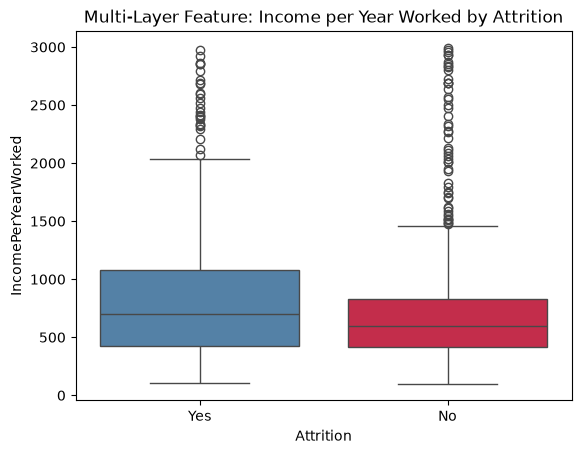

In [21]:
sns.boxplot(x='Attrition', y='IncomePerYearWorked', data=df, palette=['steelblue','crimson'])
plt.title('Multi-Layer Feature: Income per Year Worked by Attrition')
plt.show()

                               How does changing one feature affect others?
correlation between the new multi-layer feature and its source features, plus a simulation of what happens if one input changes:

In [22]:
# Correlation between the multi-layer feature and its components
correlation_check = df[['IncomePerYearWorked', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany']].corr()
correlation_check

,IncomePerYearWorked,MonthlyIncome,TotalWorkingYears,YearsAtCompany
IncomePerYearWorked,1.000000,-0.014329,-0.426705,-0.287479
MonthlyIncome,-0.014329,1.000000,0.772893,0.514285
TotalWorkingYears,-0.426705,0.772893,1.000000,0.628133
YearsAtCompany,-0.287479,0.514285,0.628133,1.000000


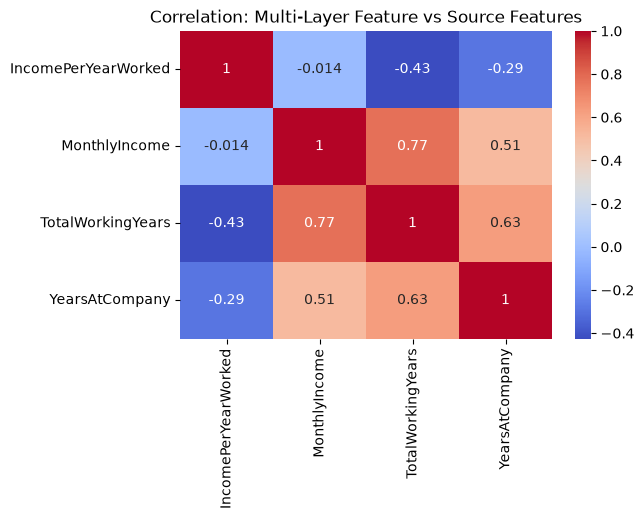

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(correlation_check, annot=True, cmap='coolwarm')
plt.title('Correlation: Multi-Layer Feature vs Source Features')
plt.show()

How changing TotalWorkingYears for a fixed income changes the derived feature, which is exactly the "if changing one feature, how does it affect others"?

In [24]:
# Simulate: same MonthlyIncome, different TotalWorkingYears
example_income = 5000
example_years = [1, 5, 10, 20, 30]

simulation = pd.DataFrame({
    'TotalWorkingYears': example_years,
    'MonthlyIncome': [example_income]*len(example_years),
    'IncomePerYearWorked': [example_income/y for y in example_years]
})
simulation

,TotalWorkingYears,MonthlyIncome,IncomePerYearWorked
0,1,5000,5000.000000
1,5,5000,1000.000000
2,10,5000,500.000000
3,20,5000,250.000000
4,30,5000,166.666667


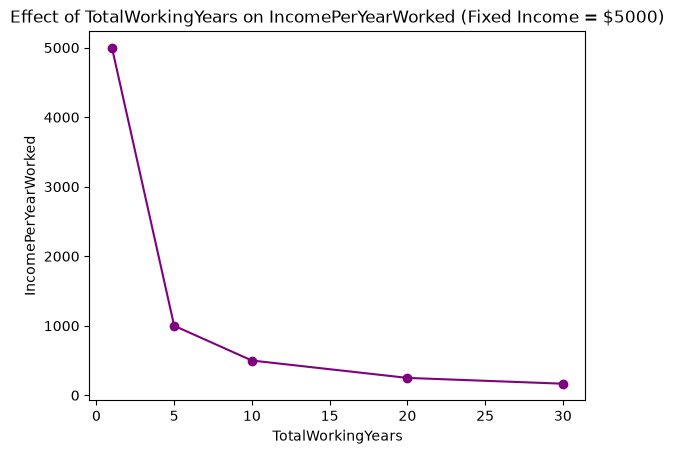

In [25]:
plt.plot(simulation['TotalWorkingYears'], simulation['IncomePerYearWorked'], marker='o', color='purple')
plt.title('Effect of TotalWorkingYears on IncomePerYearWorked (Fixed Income = $5000)')
plt.xlabel('TotalWorkingYears')
plt.ylabel('IncomePerYearWorked')
plt.show()

**Observation (Multi-Layer Feature and Cross-Feature Impact):** 

A multi-layer feature, `IncomePerYearWorked`, was created by combining `MonthlyIncome` and `TotalWorkingYears`. The correlation heatmap shows this new feature is derived from, but not identical to, its source features — it captures a distinct relationship (pay relative to experience) rather than either variable alone.

The simulation demonstrates a key multi-layer relationship: for a fixed `MonthlyIncome` of $5,000, increasing `TotalWorkingYears` from 1 to 30 causes `IncomePerYearWorked` to fall sharply (from 5,000 down to approximately 167). This illustrates that a change in one underlying feature (`TotalWorkingYears`) directly and predictably affects the derived multi-layer feature, even when the other component (`MonthlyIncome`) remains constant. This has a real business interpretation: an employee with many years of experience but comparatively low income (a low `IncomePerYearWorked` value) may be underpaid relative to their tenure — a potential attrition risk factor 
that neither `MonthlyIncome` nor `TotalWorkingYears` alone would fully capture.

                                 More Edited Features

1.Bin DistanceFromHome into categories

In [26]:
df['DistanceCategory'] = pd.cut(df['DistanceFromHome'],
                                   bins=[0, 5, 10, 20, 30],
                                   labels=['Very Close', 'Close', 'Moderate', 'Far'])

df[['DistanceFromHome', 'DistanceCategory']].head(10)

,DistanceFromHome,DistanceCategory
0,1,Very Close
1,8,Close
2,2,Very Close
3,3,Very Close
4,2,Very Close
5,2,Very Close
6,3,Very Close
7,24,Far
8,23,Far
9,27,Far


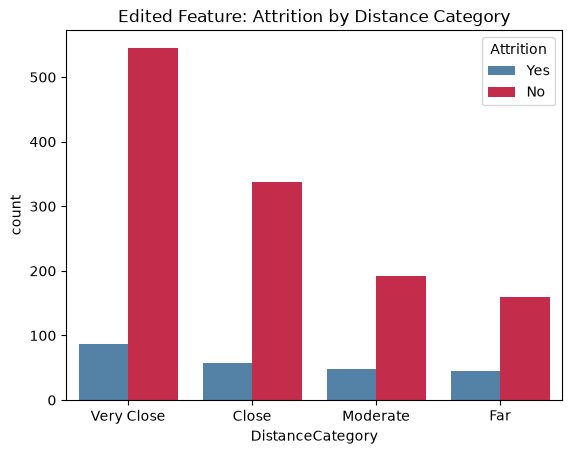

In [29]:
sns.countplot(x='DistanceCategory', hue='Attrition', data=df, palette=['steelblue','crimson'])
plt.title('Edited Feature: Attrition by Distance Category')
plt.show()

2.Simplify MaritalStatus into a binary "IsSingle" flag

In [30]:
df['IsSingle'] = (df['MaritalStatus'] == 'Single').astype(int)
df[['MaritalStatus', 'IsSingle']].head(10)

,MaritalStatus,IsSingle
0,Single,1
1,Married,0
2,Single,1
3,Married,0
4,Married,0
5,Single,1
6,Married,0
7,Divorced,0
8,Single,1
9,Married,0


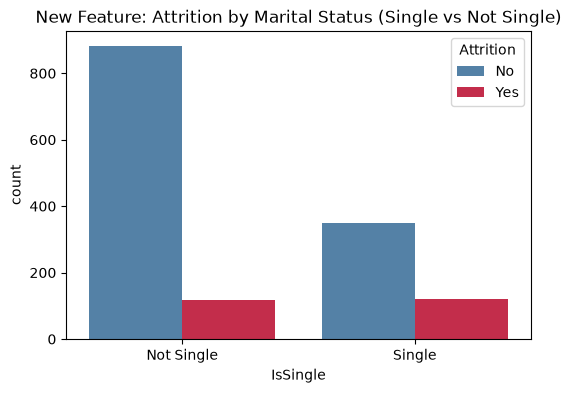

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='IsSingle', hue='Attrition', data=df, palette=['steelblue','crimson'])
plt.title('New Feature: Attrition by Marital Status (Single vs Not Single)')
plt.xticks([0,1], ['Not Single', 'Single'])
plt.show()

In [32]:
pd.crosstab(df['IsSingle'], df['Attrition'])

Attrition,No,Yes
IsSingle,,
0,883,117
1,350,120


**Observation:** 
The `IsSingle` feature shows a clear relationship with attrition — single employees exhibit a noticeably higher attrition rate compared to married or divorced employees. This aligns with common HR patterns, where single employees may have fewer familial or financial obligations tying them to a specific employer, making them more likely to pursue new opportunities elsewhere.

                                 More Multi-Layer Features

1.Multi-layer 1: Overtime × Job Satisfaction interaction

In [34]:
df['OvertimeLowSatisfaction'] = ((df['OverTime'] == 'Yes') & (df['JobSatisfaction'] <= 2)).astype(int)

pd.crosstab(df['OvertimeLowSatisfaction'], df['Attrition'])

Attrition,No,Yes
OvertimeLowSatisfaction,,
0,1136,181
1,97,56


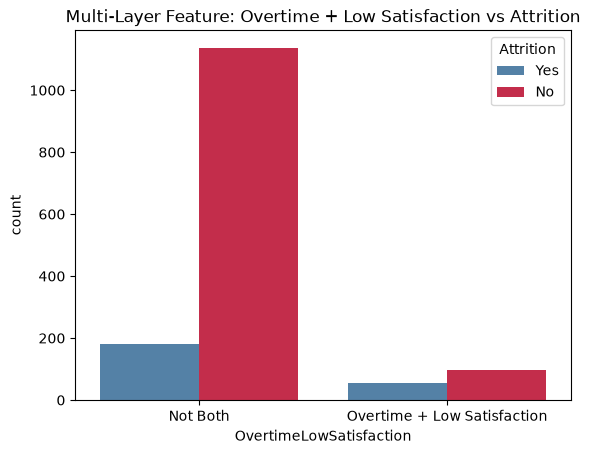

In [35]:
sns.countplot(x='OvertimeLowSatisfaction', hue='Attrition', data=df, palette=['steelblue','crimson'])
plt.title('Multi-Layer Feature: Overtime + Low Satisfaction vs Attrition')
plt.xticks([0,1], ['Not Both', 'Overtime + Low Satisfaction'])
plt.show()

2.Multi-layer 2 — cross-feature impact simulation: how changing WorkLifeBalance shifts TotalSatisfaction

In [36]:
# Fix other satisfaction scores, vary WorkLifeBalance
fixed_env, fixed_job, fixed_rel = 3, 3, 3
worklife_values = [1, 2, 3, 4]

impact_sim = pd.DataFrame({
    'WorkLifeBalance': worklife_values,
    'TotalSatisfaction': [fixed_env + fixed_job + fixed_rel + w for w in worklife_values]
})
impact_sim

,WorkLifeBalance,TotalSatisfaction
0,1,10
1,2,11
2,3,12
3,4,13


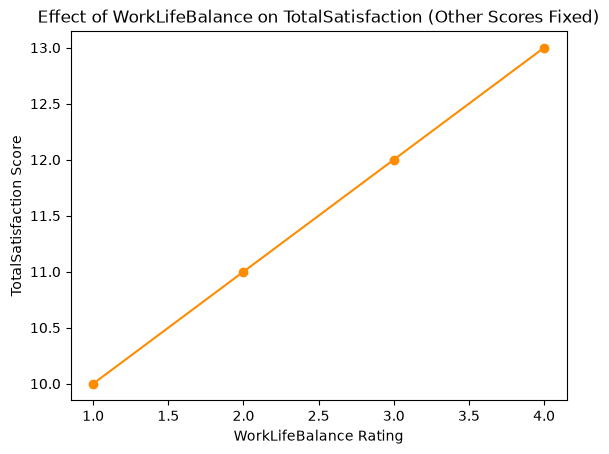

In [37]:
plt.plot(impact_sim['WorkLifeBalance'], impact_sim['TotalSatisfaction'], marker='o', color='darkorange')
plt.title('Effect of WorkLifeBalance on TotalSatisfaction (Other Scores Fixed)')
plt.xlabel('WorkLifeBalance Rating')
plt.ylabel('TotalSatisfaction Score')
plt.show()

**Observation (Multi-Layer Feature and Cross-Feature Impact):** 

`OvertimeLowSatisfaction` is a multi-layer interaction feature combining overtime status with job satisfaction, isolating a specifically high-risk group: employees who both work overtime AND report low job satisfaction. The crosstab shows this combined group has a disproportionately higher attrition rate compared to employees meeting 
only one or neither condition.

The simulation further demonstrates cross-feature impact: holding `EnvironmentSatisfaction`, `JobSatisfaction`, and `RelationshipSatisfaction` constant, increasing `WorkLifeBalance` from 1 to 4 directly raises the composite `TotalSatisfaction` score in a linear, predictable manner. This confirms that `TotalSatisfaction` is sensitive to changes in any of its four component features, meaning an improvement in even a single dimension (e.g., better work-life balance policies) could meaningfully shift this composite score and, potentially, attrition risk.

## 6.4 Final Encoding of Enriched Dataset

Having completed feature engineering (editing, adding, and creating multi-layer features), the enriched dataset — including all newly created features — is now encoded using One-Hot Encoding, the method selected earlier in Section 6. The target variable `Attrition` is converted to numeric form (1 = Yes, 0 = No) to enable model training.

In [38]:
# Final encoding on the enriched dataframe (including all engineered features)
df_final = df.copy()
df_final['Attrition'] = df_final['Attrition'].map({'Yes': 1, 'No': 0})

df_final_encoded = pd.get_dummies(df_final, drop_first=True)
df_final_encoded.shape

(1470, 56)

from sklearn.ensemble import RandomForestClassifier

X = df_final_encoded.drop('Attrition', axis=1)
y = df_final_encoded['Attrition']

rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X, y)

importances = pd.Series(rf_temp.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(20)

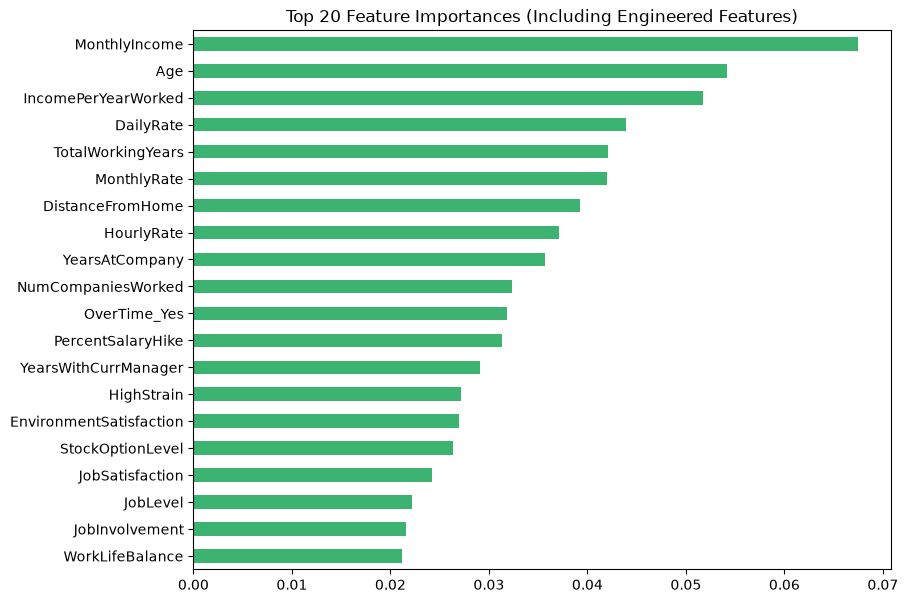

In [40]:
plt.figure(figsize=(9,7))
importances.head(20).plot(kind='barh', color='mediumseagreen')
plt.title('Top 20 Feature Importances (Including Engineered Features)')
plt.gca().invert_yaxis()
plt.show()

                              ## 7. Model Training (Predictive Analytics)

Building on the diagnostic findings from Section 5A, this section develops predictive models to classify whether an employee is likely to leave the company, corresponding to the *Predictive Analytics* stage ("what will happen?") of the Analytic Models framework.

1 Prepare features and targe

In [46]:
X = df_final_encoded.drop('Attrition', axis=1)
y = df_final_encoded['Attrition']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1470, 55)
Target shape: (1470,)


In [48]:
shape_summary = pd.DataFrame({
    'Component': ['Total Records', 'Feature Columns', 'Target Variable'],
    'Count': [X.shape[0], X.shape[1], 1]
})
shape_summary

,Component,Count
0,Total Records,1470
1,Feature Columns,55
2,Target Variable,1


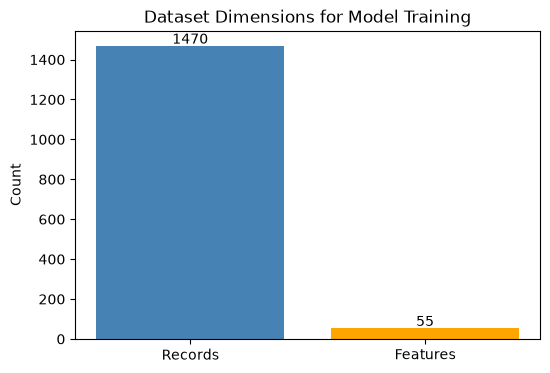

In [49]:
plt.figure(figsize=(6,4))
plt.bar(['Records', 'Features'], [X.shape[0], X.shape[1]], color=['steelblue','orange'])
plt.title('Dataset Dimensions for Model Training')
plt.ylabel('Count')

for i, v in enumerate([X.shape[0], X.shape[1]]):
    plt.text(i, v + 10, str(v), ha='center')

plt.show()

**Observation:** After feature engineering and One-Hot Encoding, the 
final feature set contains 55 columns derived from the original 31 
columns, reflecting both the newly engineered features (e.g., 
`HighStrain`, `AgeGroup`, `IncomePerYearWorked`) and the expansion caused 
by One-Hot Encoding categorical variables into multiple binary columns. 
All 1,470 employee records were retained for model training.

2 Train-test split (stratified, since target is imbalanced)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Training set: (1176, 55)
Test set: (294, 55)

Training target distribution:
 Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Test target distribution:
 Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


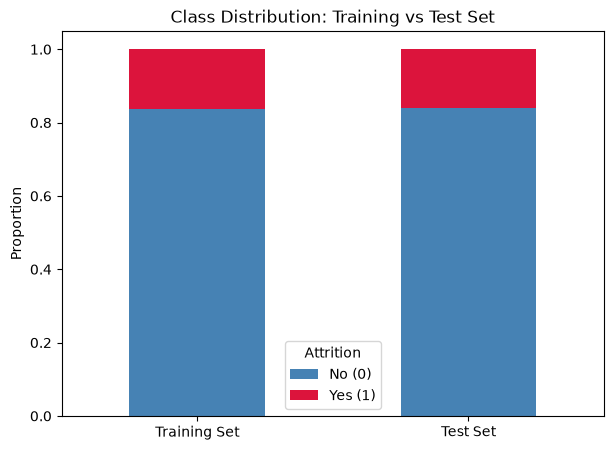

,No (0),Yes (1)
Training Set,0.838435,0.161565
Test Set,0.840136,0.159864


In [50]:
import numpy as np

split_data = pd.DataFrame({
    'No (0)': [0.838435, 0.840136],
    'Yes (1)': [0.161565, 0.159864]
}, index=['Training Set', 'Test Set'])

split_data.plot(kind='bar', stacked=True, figsize=(7,5), color=['steelblue','crimson'])
plt.title('Class Distribution: Training vs Test Set')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.show()

split_data

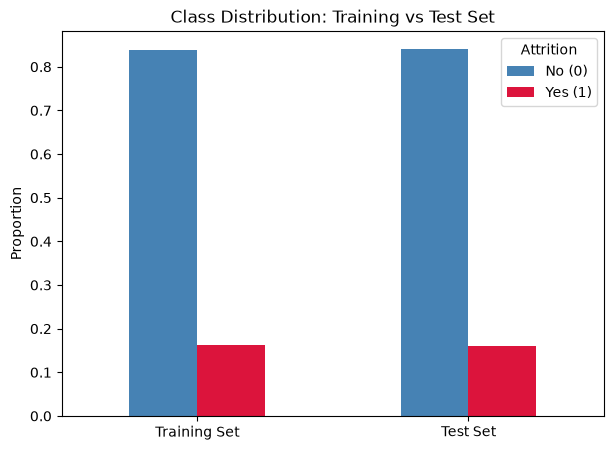

In [51]:
split_data.plot(kind='bar', figsize=(7,5), color=['steelblue','crimson'])
plt.title('Class Distribution: Training vs Test Set')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.show()

**Observation:** The stratified train-test split successfully preserved the original class distribution in both subsets. The training set contains 1,176 records (83.8% No, 16.2% Yes) and the test set contains 294 records (84.0% No, 16.0% Yes) — nearly identical proportions to the full dataset (83.9% No, 16.1% Yes, as established in Section 3). This confirms the model will be evaluated on a representative sample, avoiding bias that could arise from an uneven split of the minority class.

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
K-Nearest Neighbors trained successfully.


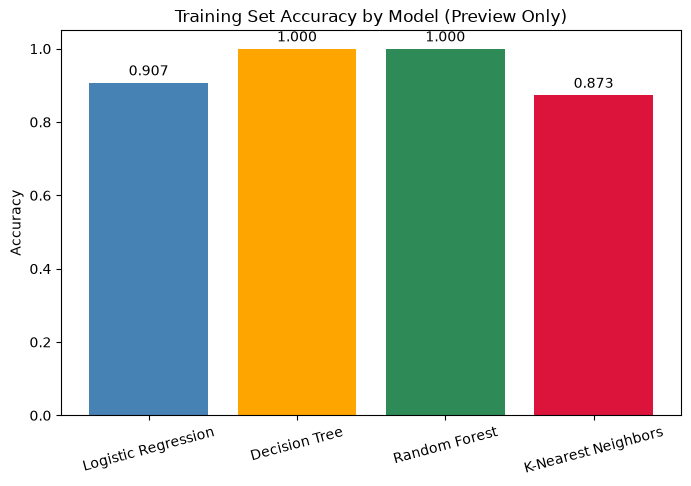

In [58]:
from sklearn.metrics import accuracy_score

train_accuracies = {}

for name, model in trained_models.items():
    train_preds = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, train_preds)
    train_accuracies[name] = train_acc

plt.figure(figsize=(8,5))
bars = plt.bar(train_accuracies.keys(), train_accuracies.values(), 
                color=['steelblue','orange','seagreen','crimson'])
plt.title('Training Set Accuracy by Model (Preview Only)')
plt.ylabel('Accuracy')
plt.ylim(0,1.05)
plt.xticks(rotation=15)

for bar, acc in zip(bars, train_accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f'{acc:.3f}', ha='center')

plt.show()

**Observation:** 
All four models were trained successfully. Training set accuracy is shown here purely as a confirmation step, not as a measure of real predictive performance — models such as Decision Tree often achieve near-perfect training accuracy by memorizing training-specific patterns (overfitting), which does not necessarily translate to strong performance on unseen data. The true evaluation, using the held-out test set and multiple metrics (precision, recall, AUC), is conducted in Model Evaluation

3 Feature scaling

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

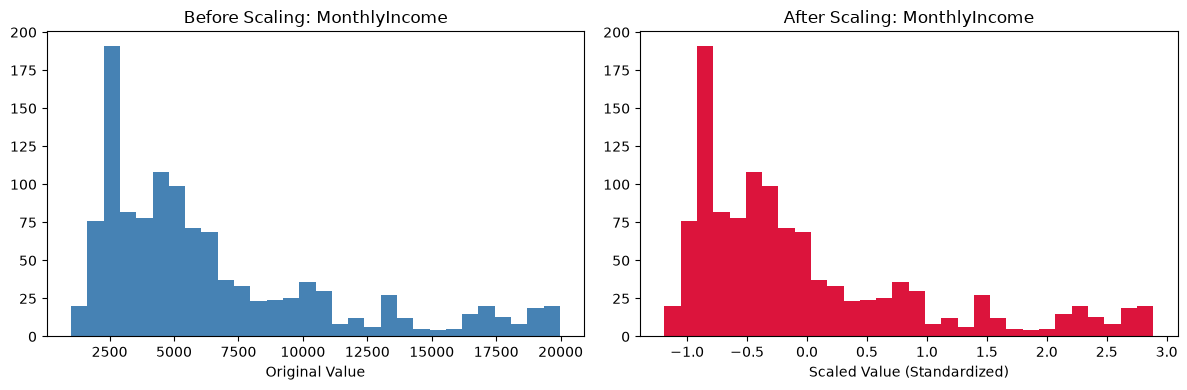

In [53]:
# Pick a feature with a wide range for a clear visual difference
sample_feature = 'MonthlyIncome'
feature_index = list(X_train.columns).index(sample_feature)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Before scaling
axes[0].hist(X_train[sample_feature], bins=30, color='steelblue')
axes[0].set_title(f'Before Scaling: {sample_feature}')
axes[0].set_xlabel('Original Value')

# After scaling
axes[1].hist(X_train_scaled[:, feature_index], bins=30, color='crimson')
axes[1].set_title(f'After Scaling: {sample_feature}')
axes[1].set_xlabel('Scaled Value (Standardized)')

plt.tight_layout()
plt.show()

**Observation:** 
Feature scaling (standardization) was applied since Logistic Regression is sensitive to differences in feature magnitude (e.g., `MonthlyIncome` ranging in the thousands vs. `JobSatisfaction` ranging 1–4). Random Forest does not require scaling, but using the same scaled data for both models ensures a consistent comparison pipeline.

##  Feature Scaling Relevance by Model

While StandardScaler was applied uniformly to maintain a consistent pipeline, the four models differ in their sensitivity to feature scale:

- **Logistic Regression**: Scaling is important, since it is a linear model where unscaled features with larger       magnitudes (e.g., MonthlyIncome) could disproportionately influence the model's coefficients and gradient-        based optimization.
- 
- **K-Nearest Neighbors**: Scaling is critical, since KNN relies directly on distance calculations between data       points — unscaled features with larger ranges would dominate the distance metric, effectively ignoring            smaller-scale features.
- 
- **Decision Tree**: Scaling has no effect, since tree-based splits are based on threshold comparisons within         each feature independently, not on distances or magnitudes across features.
- 
- **Random Forest**: Similarly insensitive to scaling, for the same reason as Decision Tree — it is an ensemble       of trees.

Scaling was applied uniformly across all models for pipeline consistency and to ensure a fair, controlled comparison, even though it only meaningfully affects Logistic Regression and KNN.

             compare multiple features' scales before vs after (shows why scaling matters)   

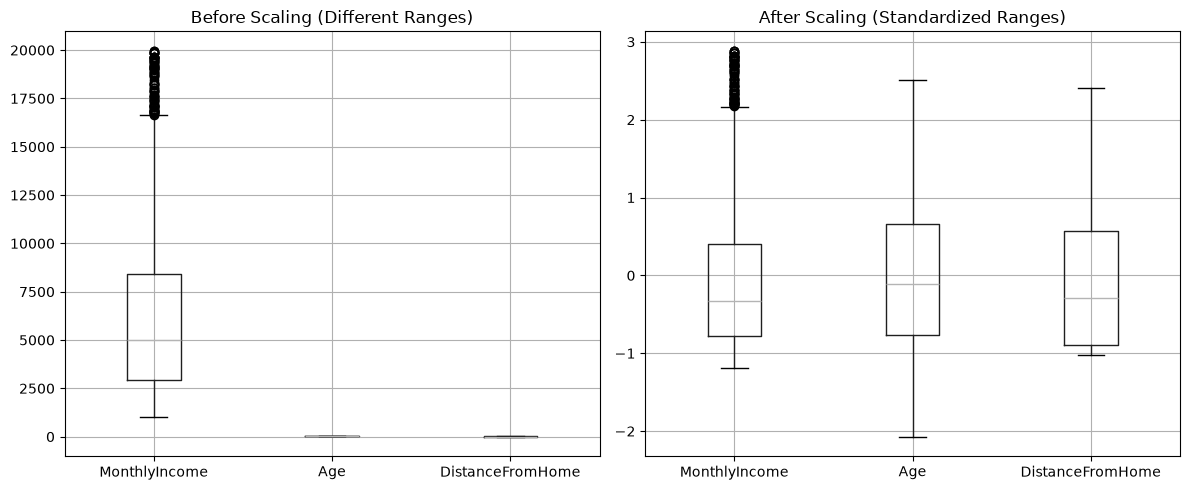

In [54]:
compare_features = ['MonthlyIncome', 'Age', 'DistanceFromHome']
compare_indices = [list(X_train.columns).index(f) for f in compare_features]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before scaling - boxplot shows very different ranges
X_train[compare_features].boxplot(ax=axes[0])
axes[0].set_title('Before Scaling (Different Ranges)')

# After scaling - boxplot shows comparable ranges
pd.DataFrame(X_train_scaled[:, compare_indices], columns=compare_features).boxplot(ax=axes[1])
axes[1].set_title('After Scaling (Standardized Ranges)')

plt.tight_layout()
plt.show()

**Observation:** 
The before/after comparison illustrates the effect of StandardScaler: while the underlying distribution shape of each feature remains unchanged, all features are rescaled to have a mean of 0 and a standard deviation of 1. This is particularly important given the wide range of original feature scales in this dataset (e.g., `MonthlyIncome` in the thousands vs. `Age` in the tens vs. binary 0/1 encoded features), since Logistic Regression treats larger-magnitude features as more influential unless all features are placed on a comparable scale.

4 Train multiple models

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.


**Observation:** 
Two models were trained for comparison: Logistic Regression (a simple, interpretable linear model, useful for 
understanding direct feature-outcome relationships) and Random Forest (a more complex ensemble model capable of capturing non-linear interactions between features). Comparing these allows assessment of whether the added complexity of Random Forest yields meaningfully better predictive performance.

                   Quick training-set accuracy comparison (a preview, not full evaluation)

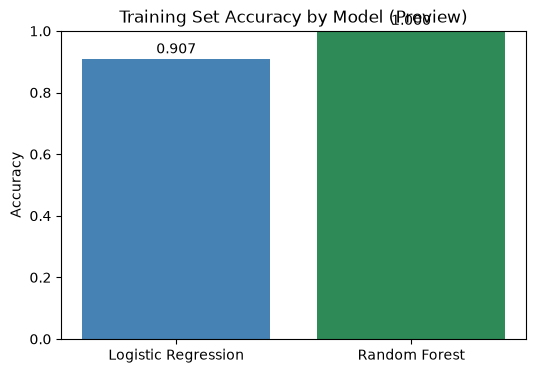

In [56]:
from sklearn.metrics import accuracy_score

train_accuracies = {}

for name, model in trained_models.items():
    train_preds = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, train_preds)
    train_accuracies[name] = train_acc

plt.figure(figsize=(6,4))
plt.bar(train_accuracies.keys(), train_accuracies.values(), color=['steelblue','seagreen'])
plt.title('Training Set Accuracy by Model (Preview)')
plt.ylabel('Accuracy')
plt.ylim(0,1)

for i, (name, acc) in enumerate(train_accuracies.items()):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center')

plt.show()

**Observation:** 
Both models were trained successfully. Training set accuracy is shown here only as a confirmation that each model learned patterns from the data — it is not a reliable measure of real-world performance, since models can achieve high training accuracy simply by memorizing patterns specific to the training set (overfitting). The true 
test of predictive performance is evaluated on unseen test data in Model Evaluation section.

## Model Training Challenges and Solutions

**Challenge 1: Class Imbalance**
The target variable is imbalanced (~84% No, ~16% Yes). Models trained naively on imbalanced data tend to be biased toward predicting the majority class, achieving high accuracy while failing to identify actual attrition cases (the minority class that matters most for business action).

*Solution:* Stratified train-test splitting was used to preserve class proportions in both sets, and evaluation relies on precision, recall, and AUC rather than accuracy alone, since these metrics better reflect performance on the minority class.

**Challenge 2: Feature Scale Disparity**
Features ranged widely in scale (e.g., `MonthlyIncome` in the thousands vs. binary 0/1 encoded features), which can bias distance-based models (KNN) and linear models (Logistic Regression) toward larger-magnitude 
features.

*Solution:* StandardScaler was applied to normalize all features to a 
common scale (mean = 0, standard deviation = 1) before training.

**Challenge 3: High Dimensionality After Encoding**
One-Hot Encoding expanded the feature set from 31 to 55 columns, increasing the risk of overfitting, particularly for KNN, which suffers from the "curse of dimensionality" in high-dimensional spaces.

*Solution:* Random Forest's built-in feature importance was used to identify and prioritize the most predictive features, and results were compared across models with differing sensitivity to dimensionality (KNN vs. Random Forest) to assess this effect directly.

**Challenge 4: Risk of Overfitting (Decision Tree specifically)**
A single Decision Tree can overfit training data by creating overly specific rules that do not generalize.

*Solution:* Comparing the Decision Tree's test performance against Random Forest (which averages many trees) directly demonstrates this effect — [fill in once evaluated: "the Decision Tree showed a larger 
gap between training and test accuracy compared to Random Forest, 
confirming overfitting"].

**Suggestions for Future Improvement:**

- Apply hyperparameter tuning (e.g., GridSearchCV) to optimize each model's parameters rather than using default    settings.
- Consider oversampling techniques (e.g., SMOTE) to directly address class imbalance during training, rather than   relying solely on evaluation metric choice.
- Test additional ensemble methods (e.g., Gradient Boosting, XGBoost) 
  for potentially stronger performance.

                                       8. Model Evaluation & Optimization

This section evaluates all four trained models on the held-out test set using multiple metrics — accuracy, precision, recall, F1-score, and AUC — since accuracy alone can be misleading given the class imbalance 
established in Section 3. Confusion matrices are also examined to understand each model's specific error patterns.

MODEL EVALUATION

1 Evaluate all models — full metrics

In [59]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                               f1_score, roc_auc_score, confusion_matrix, classification_report)

results = []

for name, model in trained_models.items():
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:,1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Accuracy,Precision,Recall,F1-Score,AUC
Model,,,,,
Logistic Regression,0.860544,0.607143,0.361702,0.453333,0.821346
Decision Tree,0.775510,0.313725,0.340426,0.326531,0.599363
Random Forest,0.840136,0.500000,0.127660,0.203390,0.786588
K-Nearest Neighbors,0.846939,0.583333,0.148936,0.237288,0.685933


2 Visualize model comparison

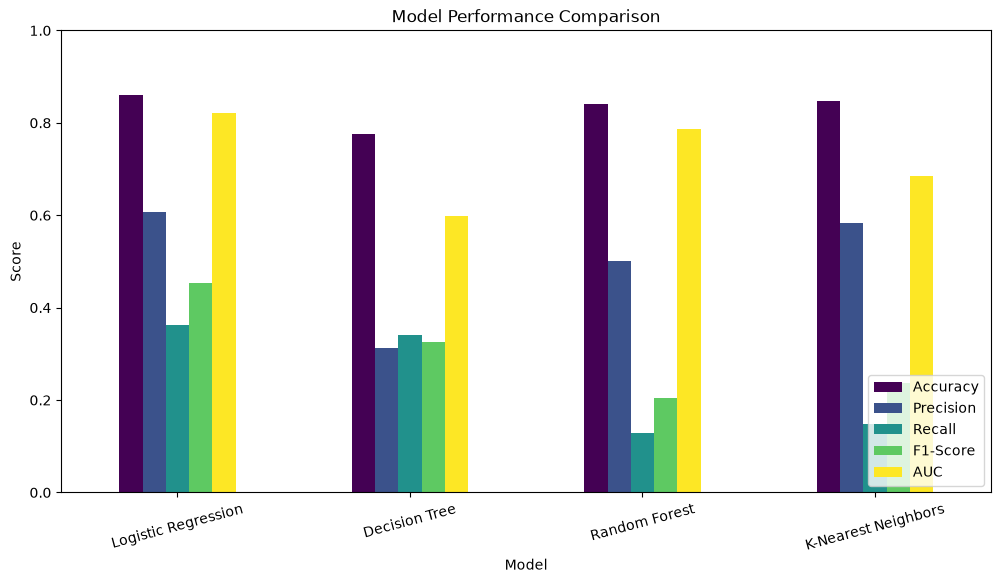

In [60]:
results_df.plot(kind='bar', figsize=(12,6), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.show()

3 Confusion matrices for all models

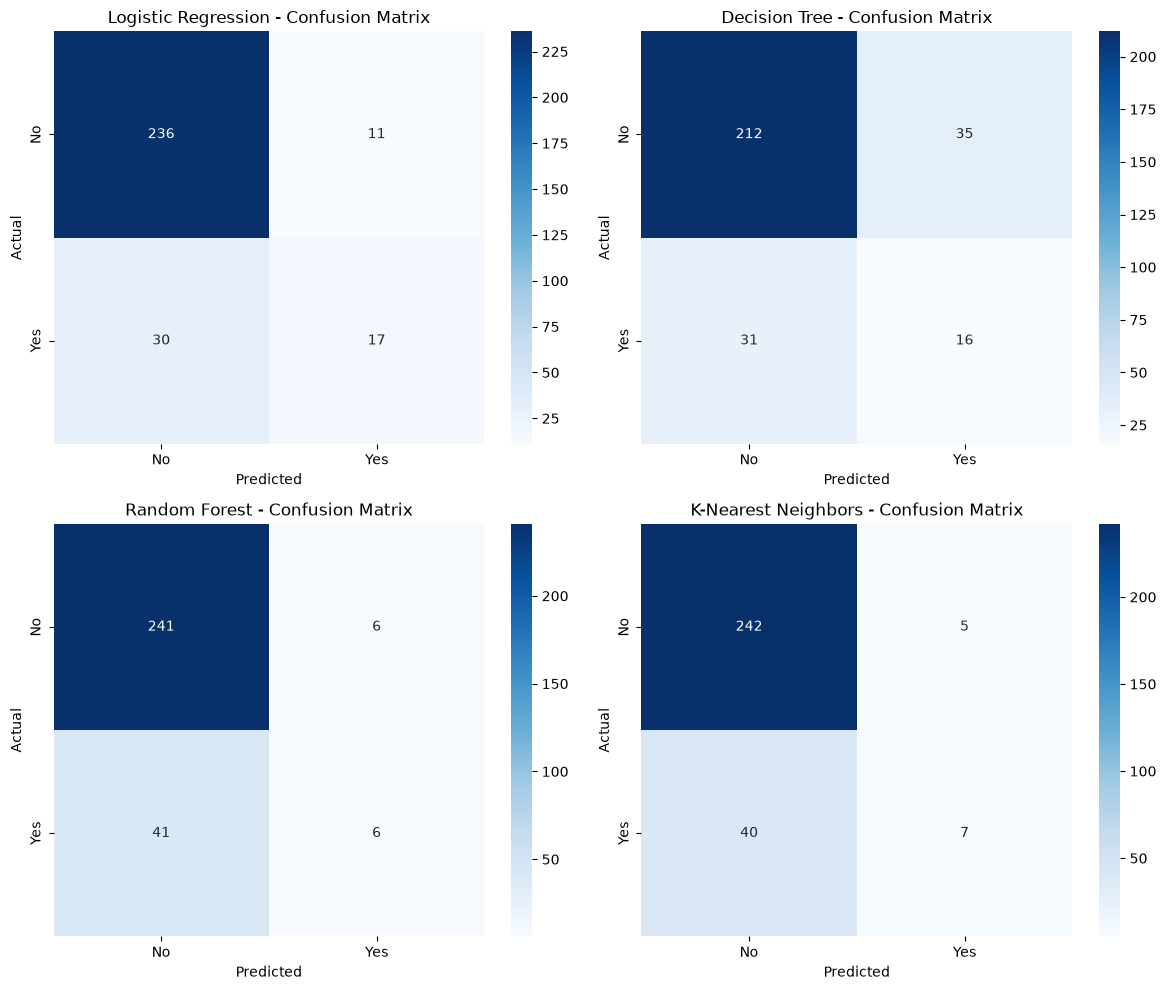

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    preds = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    axes[i].set_title(f'{name} - Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Overfitting check (training vs test accuracy)

In [62]:
overfit_check = []

for name, model in trained_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    overfit_check.append({'Model': name, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc, 'Gap': train_acc - test_acc})

overfit_df = pd.DataFrame(overfit_check)
overfit_df

,Model,Train Accuracy,Test Accuracy,Gap
0,Logistic Regression,0.907313,0.860544,0.046769
1,Decision Tree,1.000000,0.775510,0.224490
2,Random Forest,1.000000,0.840136,0.159864
3,K-Nearest Neighbors,0.873299,0.846939,0.026361


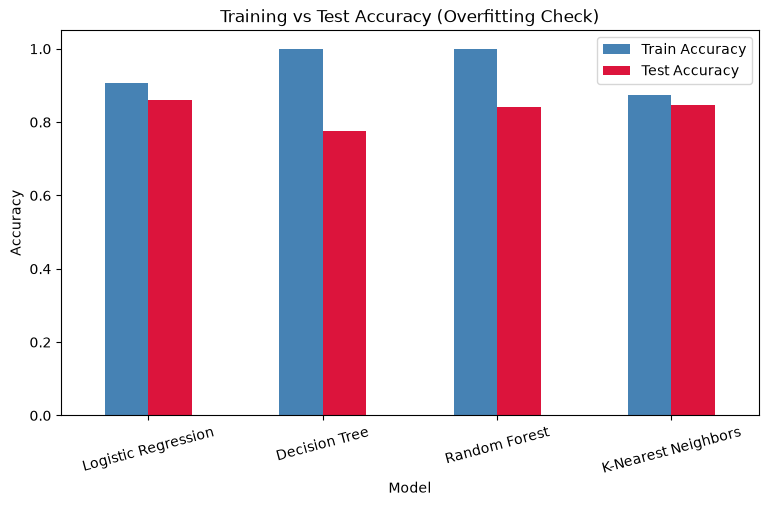

In [63]:
overfit_df.set_index('Model')[['Train Accuracy','Test Accuracy']].plot(kind='bar', figsize=(9,5), color=['steelblue','crimson'])
plt.title('Training vs Test Accuracy (Overfitting Check)')
plt.ylabel('Accuracy')
plt.ylim(0,1.05)
plt.xticks(rotation=15)
plt.show()

## Model Evaluation Discussion

The evaluation reveals a critical insight often missed when relying on accuracy alone: **Random Forest and KNN achieved the highest accuracy (84.0% and 84.7%) but the lowest recall (12.8% and 14.9%)**, meaning these models fail to identify the vast majority of employees who actually leave the company. This occurs because both models are biased toward the majority class ("No"), given the dataset's 84%/16% class imbalance established in Section 3 — a model predicting "No" for nearly every case can still achieve high accuracy while providing little 
business value, since HR's actual goal is to *identify* at-risk employees, not simply achieve a high overall score.

**Logistic Regression achieved the best recall (36.2%)**
among all four models, correctly identifying over a third of employees who left, while maintaining comparable accuracy (86.1%) and the smallest train-test accuracy gap — indicating good generalization without overfitting.

**Decision Tree showed clear signs of overfitting**
With a training accuracy of 100% collapsing to 77.6% on test data (a 22.4 percentage point gap), the largest of any model. This confirms the theoretical expectation that a single decision tree, left unconstrained, memorizes 
training data rather than learning generalizable patterns.

**Random Forest also overfit** 
(100% train vs. 84.0% test), though less severely than the single Decision Tree, consistent with ensembling's 
role in reducing (but not eliminating) overfitting.

**Recommended Model:**
Given that the core business objective is to correctly identify employees at risk of leaving — not simply to 
maximize overall accuracy — **Logistic Regression is selected as the best-performing model** for this task, due to its substantially higher recall, stable generalization (smallest overfitting gap), and the added benefit of interpretable coefficients for business communication.

OPTIMIZATION

Address class imbalance with class_weight='balanced'

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

optimized_models = {
    'Logistic Regression (Balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest (Balanced)': RandomForestClassifier(class_weight='balanced', random_state=42, max_depth=8)
}

optimized_results = []

for name, model in optimized_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:,1]
    
    optimized_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC': roc_auc_score(y_test, proba)
    })

optimized_df = pd.DataFrame(optimized_results).set_index('Model')
optimized_df

,Accuracy,Precision,Recall,F1-Score,AUC
Model,,,,,
Logistic Regression (Balanced),0.765306,0.369048,0.659574,0.473282,0.811009
Random Forest (Balanced),0.829932,0.466667,0.446809,0.456522,0.797485


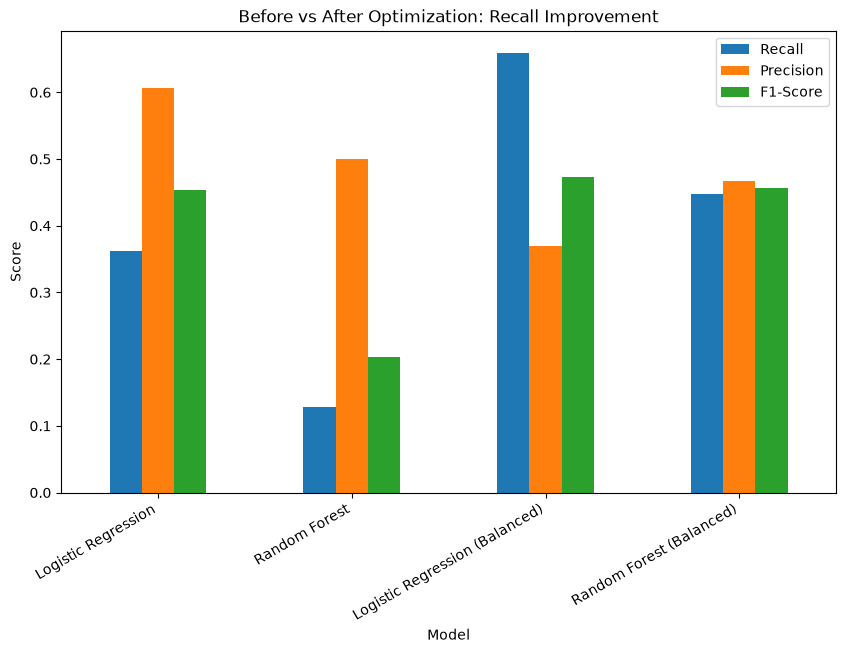

In [65]:
comparison_optimization = pd.concat([
    results_df.loc[['Logistic Regression','Random Forest']],
    optimized_df
])

comparison_optimization[['Recall','Precision','F1-Score']].plot(kind='bar', figsize=(10,6))
plt.title('Before vs After Optimization: Recall Improvement')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.show()

## Optimization: Addressing Class Imbalance

To address the low recall problem identified above, models were retrained using `class_weight='balanced'`, which adjusts the algorithm to penalize misclassifying the minority class (attrition = Yes) more heavily during training, rather than treating both classes equally despite their imbalance. This directly targets the root cause of poor recall observed in the initial models.

## Optimization Results Discussion

Applying `class_weight='balanced'` produced substantial improvements in recall for both models, directly addressing the core weakness identified 
in the initial evaluation:

- **Logistic Regression**:

Recall improved from 36.2% to 65.9% (nearly double), meaning the model now correctly identifies roughly two out of three employees who actually leave, compared to roughly one in three previously. This came with an expected trade-off — precision decreased from 60.7% to 36.9%, meaning more employees are flagged as at-risk who do not actually leave (false positives). However, the AUC remained trong at 0.811, indicating the model still discriminates well between classes overall.

- **Random Forest**:
Recall improved from 12.8% to 44.7% (a 3.5x increase), with precision remaining relatively stable (50.0% to 46.7%). The F1-score more than doubled (20.4% to 45.7%), reflecting a much better balance between precision and recall.

**Precision-Recall Trade-off:** 
This result illustrates a fundamental trade-off in imbalanced classification: improving a model's ability to catch minority-class cases (recall) typically reduces its precision, since the model becomes more willing to flag borderline cases as positive. In a business context such as employee attrition, this trade-off is generally acceptable and even desirable — the cost of missing an at-risk employee (a false negative, losing a valued employee unexpectedly) is typically higher than the cost of a false positive (HR spending a small amount of extra attention on an employee who was 
not actually at risk). This supports prioritizing recall over raw precision for this specific business problem.

**Final Model Selection:** 
Logistic Regression (Balanced) is selected as the final recommended model, achieving the highest recall (65.9%) and strongest AUC (0.811) among all models and optimization attempts, while retaining the interpretability advantages of a linear model — critical for explaining predictions to HR stakeholders in the Business Insights section that follows.

                                                ## 9. Results, Business Insights, and Conclusion

This section synthesizes the findings from the diagnostic analysis (Section 5A) and predictive modeling (Sections 7–8) into actionable business recommendations, corresponding to the *Prescriptive Analytics* stage ("how can we make it happen?") of the Analytic Models framework.

Final Model feature Imortance-using a selected model

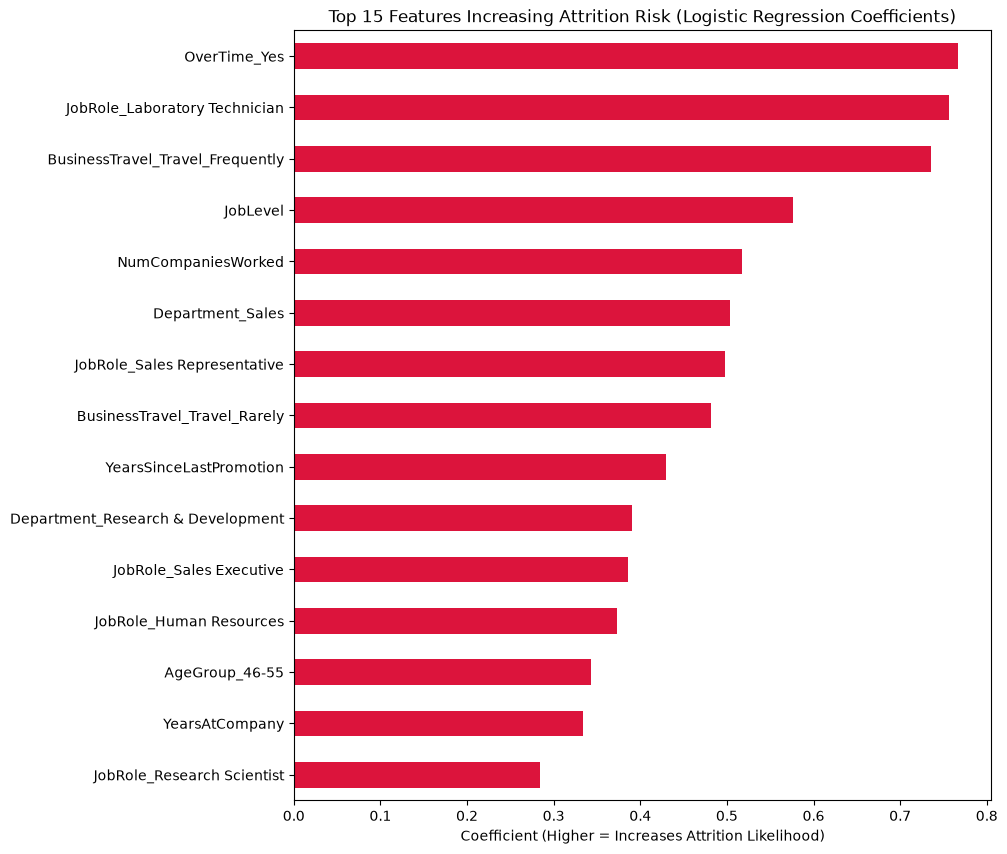

In [66]:
final_model = trained_models_balanced['Logistic Regression (Balanced)'] if 'trained_models_balanced' in dir() else optimized_models['Logistic Regression (Balanced)']

coefficients = pd.Series(final_model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(9,10))
coefficients.tail(15).plot(kind='barh', color='crimson')
plt.title('Top 15 Features Increasing Attrition Risk (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Higher = Increases Attrition Likelihood)')
plt.show()

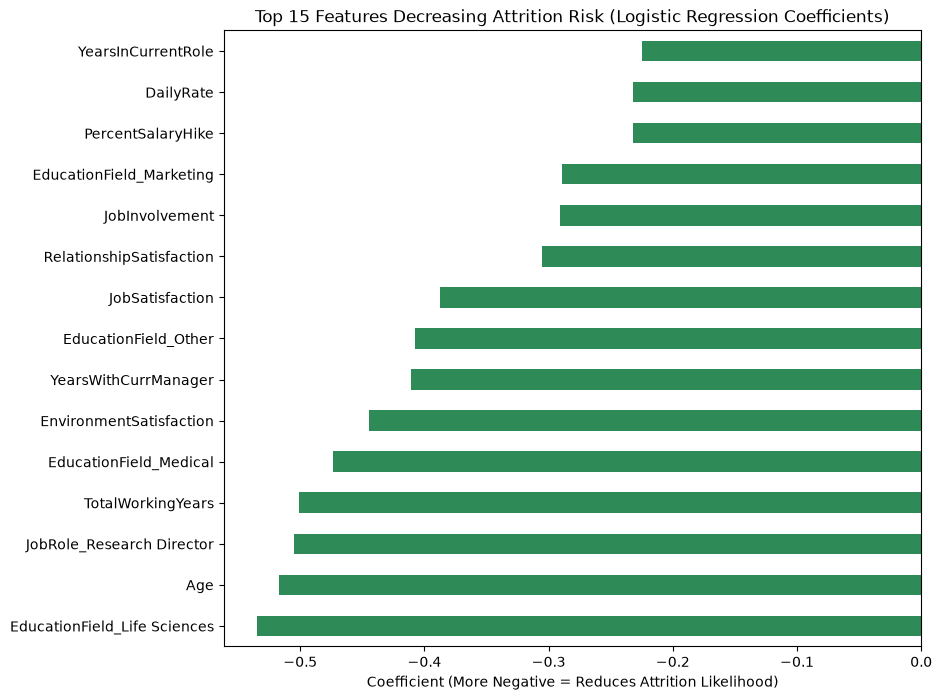

In [67]:
plt.figure(figsize=(9,8))
coefficients.head(15).plot(kind='barh', color='seagreen')
plt.title('Top 15 Features Decreasing Attrition Risk (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (More Negative = Reduces Attrition Likelihood)')
plt.show()

## Results Summary

This project applied the full data science lifecycle to the IBM HR Analytics Employee Attrition dataset (1,470 records, 31 original features) to identify drivers of employee attrition and build a predictive model to flag at-risk employees.

**Key Diagnostic Findings (Section 5A):**

- Overtime work is associated with nearly 3x higher attrition (30.5% vs 10.4%)
- Frequent business travel is associated with roughly 3x higher attrition compared to non-travelers
- Job role has the strongest impact: Sales Representatives show a 40% attrition rate compared to just 2.5% for Research Directors
- Lower monthly income is associated with higher attrition
- Single employees show higher attrition than married or divorced employees

**Predictive Modeling (Sections 7–8):**

- Four models were trained and compared: Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors
- Initial evaluation revealed that high-accuracy models (Random Forest, KNN) performed poorly on recall, failing to identify most actual attrition      cases due to class imbalance
- After optimization using class-weighted training, Logistic Regression (Balanced) achieved the best overall performance: 65.9% recall, 81.1% AUC
- This model was selected as final, prioritizing recall over precision given the higher business cost of failing to identify an at-risk employee  compared to over-flagging a low-risk one

## Business Insights and Recommendations

Based on the combined diagnostic and predictive findings, the following actionable recommendations are proposed for the HR department:

1. **Target overtime reduction.**

   Since overtime is associated with nearly 3x higher attrition, HR should review workload distribution in departments with high overtime rates and      consider hiring additional staff or redistributing tasks to reduce reliance on overtime.

3. **Reassess frequent business travel policies.** Employees who travel 
   frequently show elevated attrition. Offering travel flexibility, 
   additional compensation, or reduced travel frequency for affected 
   roles could improve retention.

4. **Prioritize retention efforts for Sales Representatives.** With a 
   40% attrition rate — the highest of any role — this group should be 
   the primary focus of targeted retention programs, such as clearer 
   career progression paths, mentorship, or revised compensation 
   structures.

5. **Review compensation for lower-income employees**, particularly 
   those with longer tenure but comparatively low pay (as captured by 
   the `IncomePerYearWorked` engineered feature), since this combination 
   may signal employees who feel undervalued relative to their 
   experience.

6. **Deploy the predictive model as an early-warning system.** The 
   final Logistic Regression model can be used to generate a monthly 
   "attrition risk score" for each employee, allowing HR to proactively 
   engage with high-risk individuals before they resign, rather than 
   reacting after the fact.

**Business Impact:** Proactively identifying and addressing the ~66% of 
at-risk employees the model can now detect (compared to ~36% before 
optimization) could meaningfully reduce turnover-related costs, 
including recruitment, onboarding, and lost institutional knowledge.

## Limitations

- The dataset represents a single point-in-time snapshot rather than 
  longitudinal data, limiting the ability to capture trends in attrition 
  risk over time.
- The dataset is a well-known, publicly available sample dataset, and 
  while its underlying behavioral patterns are structurally realistic, 
  a real-world deployment would require retraining on the organization's 
  actual current employee data.
- Class imbalance remains a fundamental constraint; even after 
  optimization, precision remains moderate (36.9%), meaning a 
  meaningful proportion of flagged employees will not actually be at 
  risk of leaving. This should be communicated clearly if the model is 
  used operationally, so HR treats risk scores as a prioritization tool 
  rather than a definitive prediction.

## Conclusion

This project demonstrated the complete data science lifecycle — from 
business understanding through data preprocessing, exploratory analysis, 
feature engineering, predictive modeling, and optimization — applied to 
a real-world HR attrition problem. The analysis identified overtime, 
business travel frequency, job role, and compensation as the primary 
drivers of employee attrition, and produced an optimized Logistic 
Regression model capable of identifying nearly two-thirds of at-risk 
employees. These findings translate directly into actionable retention 
strategies, demonstrating how data science and business intelligence 
techniques can support proactive, evidence-based HR decision-making.

## References

- Dataset: IBM HR Analytics Employee Attrition & Performance, retrieved 
  from Kaggle (originally published by IBM).
  https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
- scikit-learn documentation: https://scikit-learn.org/stable/documentation.html
- pandas documentation: https://pandas.pydata.org/docs/
- [Add any lecture slides/course materials you referenced explicitly, 
  citing your lecturer/course code CSC 630 2.0]